In [1]:
import pandas as pd
import numpy as np
import wrds
from pandas.tseries.offsets import *
import os
import pandas as pd
import numpy as np
import wrds
from random import *
from dateutil.relativedelta import *
from pandas.tseries.offsets import *
from scipy import stats
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import pandas_datareader
import datetime
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

import quantstats as qs
# extend pandas functionality with metrics, etc.
qs.extend_pandas()


# Regime-Based Long-Short Equity Trading Strategies: A Dynamic Approach to Factor Investing

## Abstract

This paper examines the performance of regime-based long-short equity trading strategies using firm-level characteristic mimicking factors derived from price and volume data. We construct trading strategies that dynamically adapt to market regimes identified through macroeconomic indicators including term structure dynamics and market concentration measures (Gini coefficient and Herfindahl-Hirschman Index). Using CRSP-WRDS data spanning 1990 to 2024, we demonstrate that regime-aware strategies significantly outperform static long-only approaches. Our methodology employs a composite Z-score ranking system within each regime, going long the top 20% of stocks and short the bottom 20% based on factor exposure.

## Introduction

Traditional factor investing approaches often assume static relationships between stock characteristics and expected returns. However, extensive research suggests that factor performance varies substantially across different market regimes. Our study builds on this foundation by proposing a dynamic approach that explicitly incorporates market regime identification and adjusts factor exposures accordingly.

The primary contribution of this research is a comprehensive framework for regime identification using both term structure indicators and market concentration metrics. We demonstrate that combining these regime signals with tailored factor exposures yields superior risk-adjusted returns compared to static factor approaches.

### Load Data from WRDS

## Data

Our study utilizes a comprehensive dataset from the Center for Research in Security Prices (CRSP) accessed through the Wharton Research Data Services (WRDS) platform. The analysis period spans from January 1990 to December 2023, encompassing multiple market regimes including bull markets, bear markets, and periods of market stress.

### Primary Data Sources:
1. **Stock Return Data**: Monthly stock returns from CRSP for all common stocks (share codes 10 and 11) listed on NYSE, AMEX, and NASDAQ (exchange codes 1, 2, and 3).
2. **Risk-Free Rate**: Treasury bill returns from CRSP's monthly Treasury indices.
3. **Fama-French Factors**: Monthly returns for the Market (Mkt-RF), Size (SMB), and Value (HML) factors.
4. **Macroeconomic Indicators**: 10-Year Treasury Rate (GS10) and 3-Month T-Bill Rate (DTB3) from the Federal Reserve Economic Data (FRED) database.

The final sample includes approximately 3,000-7,000 stocks per month after applying standard filters for data quality and liquidity. We properly account for delisting returns to avoid survivorship bias in our analysis.

In [2]:
load_data = False
wrds_id = 'kanavmehta' # Add your username

data_folder = 'data/'
fig_folder = 'figures/'

today = datetime.date.today()
current_quarter = (today.month - 1) // 3 + 1
current_year = today.year
first_month_of_current_quarter = (current_quarter - 1) * 3 + 1
first_day_of_current_quarter = datetime.date(today.year, first_month_of_current_quarter, 1)
last_day_of_previous_quarter = first_day_of_current_quarter - datetime.timedelta(days=1)

if load_data:

    # Defining dates to load data
    today = datetime.date.today()
    current_quarter = (today.month - 1) // 3 + 1
    current_year = today.year
    first_month_of_current_quarter = (current_quarter - 1) * 3 + 1
    first_day_of_current_quarter = datetime.date(today.year, first_month_of_current_quarter, 1)
    last_day_of_previous_quarter = first_day_of_current_quarter - datetime.timedelta(days=1)

    ## LOADING CRSP DATA FROM WRDS -- T-Bill data
    conn = wrds.Connection(wrds_username = wrds_id)
    rf = conn.raw_sql("""
                          select caldt, t30ret
                          from crsp.mcti
                          """)
    conn.close()
    rf['caldt'] = pd.DataFrame(rf[['caldt']].values.astype('datetime64[ns]')) + MonthEnd(0)
    rf = rf.rename(columns={"caldt":"date","t30ret":"rf"}).copy()
    conn = wrds.Connection(wrds_username=wrds_id)
    
    # Load CRSP returns and change variables format
    crsp_raw = conn.raw_sql("""
                          select a.permno, a.permco, a.date, b.shrcd, b.exchcd, b.ticker, b.comnam,
                          a.ret, a.retx, a.shrout, a.prc, a.cfacshr, a.cfacpr
                          from crspq.msf as a
                          left join crsp.msenames as b
                          on a.permno=b.permno
                          and b.namedt<=a.date
                          and a.date<=b.nameendt
                          where a.date between '01/01/1900' and '"""+last_day_of_previous_quarter.strftime("%m/%d/%Y")+"""'
                          """)
    crsp_raw = crsp_raw.sort_values(['permno','date']).reset_index(drop=True).copy()
    crsp_raw[['permno', 'permco']] = crsp_raw[['permno', 'permco']].astype(int)
    crsp_raw['date'] = pd.to_datetime(crsp_raw['date'],format='%Y-%m-%d',errors='ignore')+ MonthEnd(0)

    # Load CRSP Deslisting returns and change variables format
    dlret_raw = conn.raw_sql("""
                         select permno, dlret, dlstdt, dlstcd
                         from crspq.msedelist
                         """)
    dlret_raw = dlret_raw.sort_values(['permno','dlstdt']).reset_index(drop=True).copy()
    dlret_raw.permno    = dlret_raw.permno.astype(int)
    dlret_raw['dlstdt'] = pd.to_datetime(dlret_raw['dlstdt'])
    dlret_raw['date']  = dlret_raw['dlstdt']+MonthEnd(0)

    conn.close()
    
else:
    # load pickle
    crsp_raw  = pd.read_feather(data_folder+'crsp_raw.feather')
    dlret_raw = pd.read_feather(data_folder+'dlret_raw.feather')
    rf  = pd.read_feather(data_folder+'rf_factor_investing.feather')

In [3]:
# from Professor Herskovic's slide deck - referenced from PS1

FF3 = pandas_datareader.famafrench.FamaFrenchReader('F-F_Research_Data_Factors',start='1900', end=str(current_year+1))
FF3 = FF3.read()[0]/ 100 # Monthly data
FF3.columns = 'Mkt_minus_RF', 'SMB', 'HML', 'RF'
FF3 = FF3.reset_index().rename(columns={"Date":"date"}).copy()
FF3['date'] = pd.DataFrame(FF3[['date']].values.astype('datetime64[ns]')) + MonthEnd(0)
FF3['Year'] = FF3['date'].dt.year
FF3['Month'] = FF3['date'].dt.month

FF_mkt = FF3[['date', 'Year', 'Month', 'Mkt_minus_RF', 'SMB', 'HML', 'RF']]
FF_mkt = FF_mkt[(FF_mkt['Year'] >= 1990) & (FF_mkt['Year'] <= 2024)]

FF_mkt.head()

,date,Year,Month,Mkt_minus_RF,SMB,HML,RF
762,1990-01-31,1990,1,-0.0780,-0.0114,0.0083,0.0057
763,1990-02-28,1990,2,0.0112,0.0097,0.0065,0.0057
764,1990-03-31,1990,3,0.0183,0.0147,-0.0290,0.0064
765,1990-04-30,1990,4,-0.0336,-0.0047,-0.0257,0.0069
766,1990-05-31,1990,5,0.0843,-0.0256,-0.0389,0.0068


### Define Regime

## Methodology

Our methodological approach consists of three main components: (1) market regime identification, (2) stock characteristic factor construction, and (3) regime-based portfolio formation.

### Market Regime Identification

We employ a two-dimensional regime classification framework that incorporates both macroeconomic conditions and market concentration dynamics:

1. **Macroeconomic Regimes**: Based on the term spread between 10-Year Treasury Rate and 3-Month T-Bill Rate:
   - **Bull Market**: Term spread > 1% (indicating economic expansion)
   - **Bear Market**: Term spread < 0% (inverted yield curve, indicating potential recession)
   - **Sideways Market**: Term spread between 0% and 1% (indicating economic uncertainty)

2. **Market Concentration Regimes**: Based on Gini coefficient and Herfindahl-Hirschman Index (HHI):
   - **Narrow Market**: Concentration metrics significantly above historical average (market dominated by fewer stocks)
   - **Broad Market**: Concentration metrics significantly below historical average (market breadth)
   - **Normal Market**: Concentration metrics within normal ranges

The combination of these two dimensions creates a 3×3 matrix of nine possible market regimes, each with distinct factor performance characteristics.

In [4]:
# Define date range for macroeconomic data
start_date = '1990-01-01'
end_date = '2024-12-31'

# Fetch 10-Year Treasury Rate and 3-Month T-Bill Rate from FRED
gs10 = web.DataReader('GS10', 'fred', start_date, end_date)   # Long-term rate
dtb3 = web.DataReader('DTB3', 'fred', start_date, end_date)   # Short-term rate

# Combine into a single DataFrame and compute term spread
macro = pd.concat([gs10, dtb3], axis=1)
macro.columns = ['GS10', 'DTB3']
macro['Term_Spread'] = macro['GS10'] - macro['DTB3']

# Resample to monthly frequency, taking last available value each month
monthly_macro = macro.resample('M').last().ffill()

# Function to classify economic regime based on term spread
def classify_regime(spread):
    if spread > 1:
        return 'bull'
    elif spread < 0:
        return 'bear'
    else:
        return 'sideways'

# Assign regime labels
monthly_macro['Regime'] = monthly_macro['Term_Spread'].apply(classify_regime)

# Filter to desired date range
monthly_macro = monthly_macro.loc[start_date:end_date]

# Preview result
monthly_macro.head()

,GS10,DTB3,Term_Spread,Regime
DATE,,,,
1990-01-31,8.21,7.74,NaN,sideways
1990-02-28,8.47,7.77,0.71,sideways
1990-03-31,8.59,7.80,0.78,sideways
1990-04-30,8.79,7.79,0.78,sideways
1990-05-31,8.76,7.75,0.84,sideways


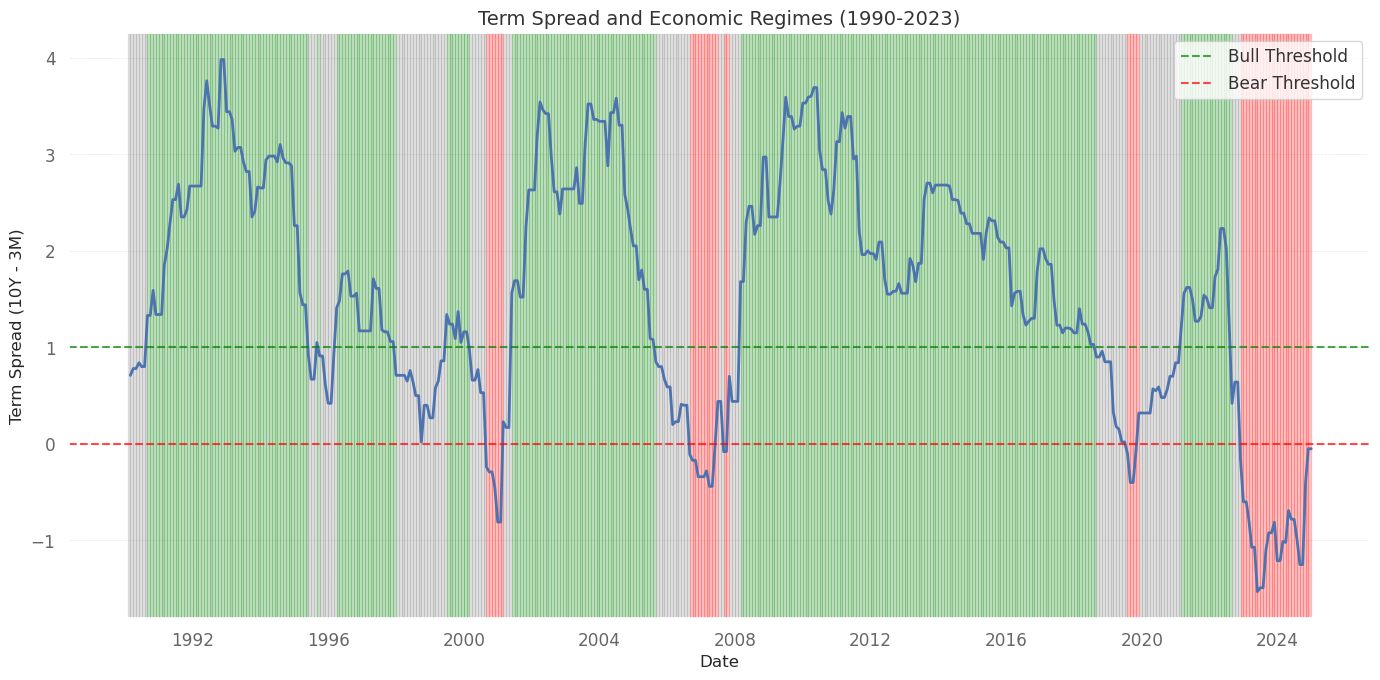

In [5]:
# Visualize the term spread and regimes
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_macro, x=monthly_macro.index, y='Term_Spread', linewidth=2)

# Add horizontal lines for regime thresholds
plt.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='Bull Threshold')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Bear Threshold')

# Color the background based on regime
dates = monthly_macro.index.tolist()
regimes = monthly_macro['Regime'].tolist()

# Plot regime background colors
for i in range(len(dates)-1):
    if regimes[i] == 'bull':
        plt.axvspan(dates[i], dates[i+1], alpha=0.2, color='green')
    elif regimes[i] == 'bear':
        plt.axvspan(dates[i], dates[i+1], alpha=0.2, color='red')
    else:
        plt.axvspan(dates[i], dates[i+1], alpha=0.2, color='gray')

plt.title('Term Spread and Economic Regimes (1990-2023)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Term Spread (10Y - 3M)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# Merge CRSP returns with delisting returns by permno and date
crsp_stocks = pd.merge(crsp_raw, dlret_raw, how='left', on=['permno', 'date'])

# Filter: keep only common stocks (shrcd 10 or 11) on NYSE (1), AMEX (2), or NASDAQ (3)
crsp_stocks = crsp_stocks[
    (crsp_stocks['shrcd'].isin([10, 11])) &
    (crsp_stocks['exchcd'].isin([1, 2, 3]))
]

crsp_stocks['mktcap'] = crsp_stocks['prc'].abs() * crsp_stocks['shrout'] * 1000

crsp_stocks['ret_adj'] = crsp_stocks['ret']
crsp_stocks.loc[crsp_stocks['dlret'].notna(), 'ret_adj'] = (1 + crsp_stocks.loc[crsp_stocks['dlret'].notna(), 'ret']) * \
                                             (1 + crsp_stocks.loc[crsp_stocks['dlret'].notna(), 'dlret']) - 1

# Keep only relevant columns for future calculations
crsp_stocks = crsp_stocks[['permno', 'date', 'shrcd', 'exchcd', 'ret_adj', 'mktcap','prc','shrout']]

# Preview the cleaned dataset
crsp_stocks.head()

,permno,date,shrcd,exchcd,ret_adj,mktcap,prc,shrout
1,10000,1986-01-31,10.0,3.0,NaN,16100000.00,-4.37500,3680.0
2,10000,1986-02-28,10.0,3.0,-0.257143,11960000.00,-3.25000,3680.0
3,10000,1986-03-31,10.0,3.0,0.365385,16330000.00,-4.43750,3680.0
4,10000,1986-04-30,10.0,3.0,-0.098592,15172000.00,-4.00000,3793.0
5,10000,1986-05-31,10.0,3.0,-0.222656,11793878.34,-3.10938,3793.0


In [7]:
def gini_coefficient(values):
    """
    Calculate Gini coefficient for a series of values
    
    Args:
        values (array-like): Series of values to calculate Gini coefficient for
        
    Returns:
        float: Gini coefficient between 0 (perfect equality) and 1 (perfect inequality)
    """
    sorted_vals = np.sort(values)
    cumvals = np.cumsum(sorted_vals)
    total = cumvals[-1]
    if total == 0:
        return 0
    n = len(values)
    # Gini formula from Lorenz curve
    return 1 - 2 * (cumvals / total).sum() / n + 1 / n
    
def herfindahl_hirschman_index(values):
    """
    Calculate Herfindahl-Hirschman Index (HHI) for market concentration
    
    Args:
        values (array-like): Series of market caps or market shares
        
    Returns:
        float: HHI between 0 (perfect competition) and 1 (monopoly)
    """
    # Convert to market shares
    total = np.sum(values)
    if total == 0:
        return 0
    market_shares = values / total
    # HHI is sum of squared market shares
    hhi = np.sum(market_shares ** 2)
    return hhi

crsp_1990 = crsp_stocks[crsp_stocks['date'] >= '1990-01-01'].copy()
crsp_1990 = crsp_1990[crsp_1990['mktcap'].notnull()].copy()

concentration_coefficients = crsp_1990.groupby('date')['mktcap'].apply(gini_coefficient)
concentration_coefficients = concentration_coefficients.reset_index()
concentration_coefficients.rename(columns={'mktcap': 'gini'}, inplace=True)
concentration_coefficients['gini'] = concentration_coefficients['gini'].shift(1)
concentration_coefficients.set_index('date', inplace=True)
hhi = crsp_1990.groupby('date')['mktcap'].apply(herfindahl_hirschman_index)
hhi = hhi.reset_index()
hhi.rename(columns={'mktcap': 'hhi'}, inplace=True)
hhi['hhi'] = hhi['hhi'].shift(1)
hhi.set_index('date', inplace=True)
concentration_coefficients = concentration_coefficients.join(hhi)
concentration_coefficients['gini_growth'] = concentration_coefficients['gini'].pct_change()
concentration_coefficients['hhi_growth'] = concentration_coefficients['hhi'].pct_change()
concentration_coefficients['gini_growth_autocorr_24m'] = concentration_coefficients['gini_growth'].rolling(window=24).apply(lambda x: x.autocorr(), raw=False)
concentration_coefficients['hhi_growth_autocorr_24m'] = concentration_coefficients['hhi_growth'].rolling(window=24).apply(lambda x: x.autocorr(), raw=False)
concentration_coefficients['gini_growth_12m_mean'] = concentration_coefficients['gini'].pct_change(12)
concentration_coefficients['hhi_growth_12m_mean'] = concentration_coefficients['hhi'].pct_change(12)
concentration_coefficients['gini_growth_24m_mean'] = concentration_coefficients['gini'].pct_change(24)
concentration_coefficients['hhi_growth_24m_mean'] = concentration_coefficients['hhi'].pct_change(24)
concentration_coefficients['gini_hist_mean'] = concentration_coefficients['gini'].expanding().mean()
concentration_coefficients['hhi_hist_mean'] = concentration_coefficients['hhi'].expanding().mean()
concentration_coefficients['gini_hist_std'] = concentration_coefficients['gini'].expanding().std()
concentration_coefficients['hhi_hist_std'] = concentration_coefficients['hhi'].expanding().std()
concentration_coefficients['gini_cum_max'] = concentration_coefficients['gini'].cummax()
concentration_coefficients['hhi_cum_max'] = concentration_coefficients['hhi'].cummax()
concentration_coefficients['hhi_regime_change_ind1'] = concentration_coefficients['hhi_growth_autocorr_24m'] < -0.3
concentration_coefficients['gini_regime_change_ind1'] = concentration_coefficients['gini_growth_autocorr_24m'] < -0.2
concentration_coefficients['hhi_concentrated'] = concentration_coefficients['hhi'] > concentration_coefficients['hhi_hist_mean'] + 0.67 * concentration_coefficients['hhi_hist_std']
concentration_coefficients['gini_concentrated'] = concentration_coefficients['gini'] > concentration_coefficients['gini_hist_mean'] + 0.67 * concentration_coefficients['gini_hist_std']
concentration_coefficients['hhi_breadth'] = concentration_coefficients['hhi'] < concentration_coefficients['hhi_hist_mean'] - 0.67 * concentration_coefficients['hhi_hist_std']
concentration_coefficients['gini_breadth'] = concentration_coefficients['gini'] < concentration_coefficients['gini_hist_mean'] - 0.67 * concentration_coefficients['gini_hist_std']
concentration_coefficients['hhi_regime'] = np.where(concentration_coefficients['hhi_concentrated'], 'Narrow',
                                                    np.where(concentration_coefficients['hhi_breadth'], 'Broad', 'Normal'))
concentration_coefficients['gini_regime'] = np.where(concentration_coefficients['gini_concentrated'], 'Narrow',
                                                    np.where(concentration_coefficients['gini_breadth'], 'Broad', 'Normal'))


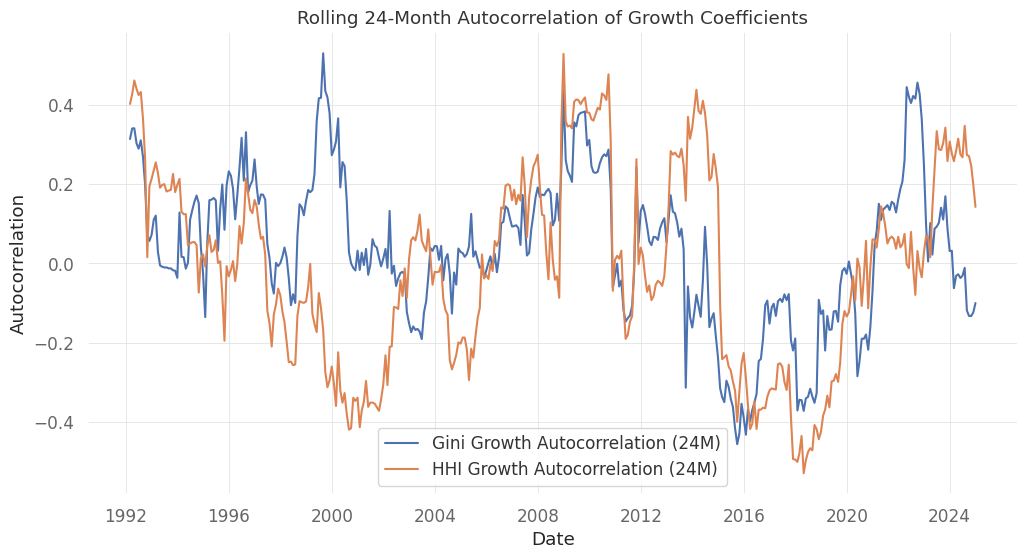

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=concentration_coefficients, x=concentration_coefficients.index, y='gini_growth_autocorr_24m', label='Gini Growth Autocorrelation (24M)')
sns.lineplot(data=concentration_coefficients, x=concentration_coefficients.index, y='hhi_growth_autocorr_24m', label='HHI Growth Autocorrelation (24M)')
plt.title('Rolling 24-Month Autocorrelation of Growth Coefficients')
plt.xlabel('Date')
plt.ylabel('Autocorrelation')
plt.legend()
plt.show()

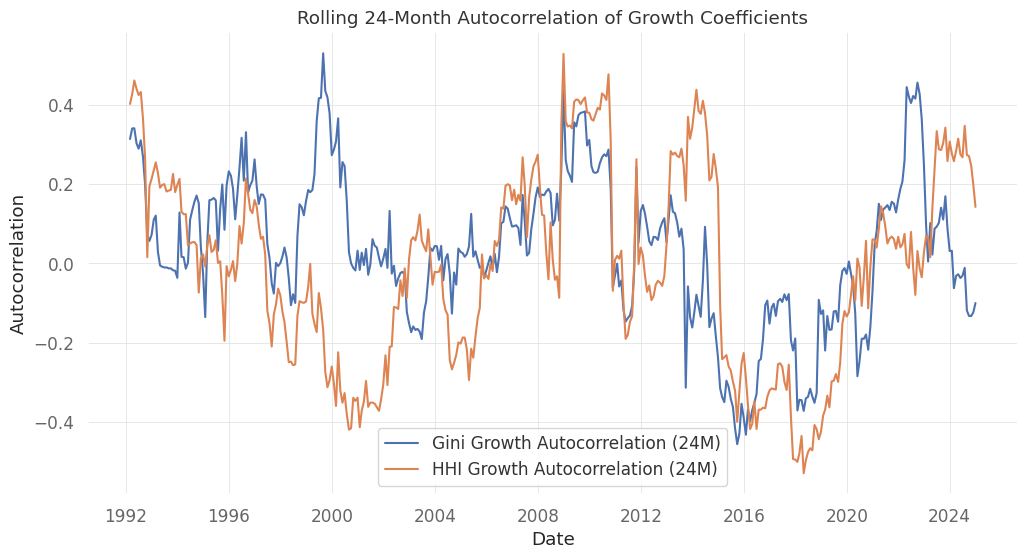

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=concentration_coefficients, x=concentration_coefficients.index, y='gini_growth_autocorr_24m', label='Gini Growth Autocorrelation (24M)')
sns.lineplot(data=concentration_coefficients, x=concentration_coefficients.index, y='hhi_growth_autocorr_24m', label='HHI Growth Autocorrelation (24M)')
plt.title('Rolling 24-Month Autocorrelation of Growth Coefficients')
plt.xlabel('Date')
plt.ylabel('Autocorrelation')
plt.legend()
plt.show()

In [10]:
monthly_macro = monthly_macro.merge(concentration_coefficients, left_index=True, right_index=True, how='left')

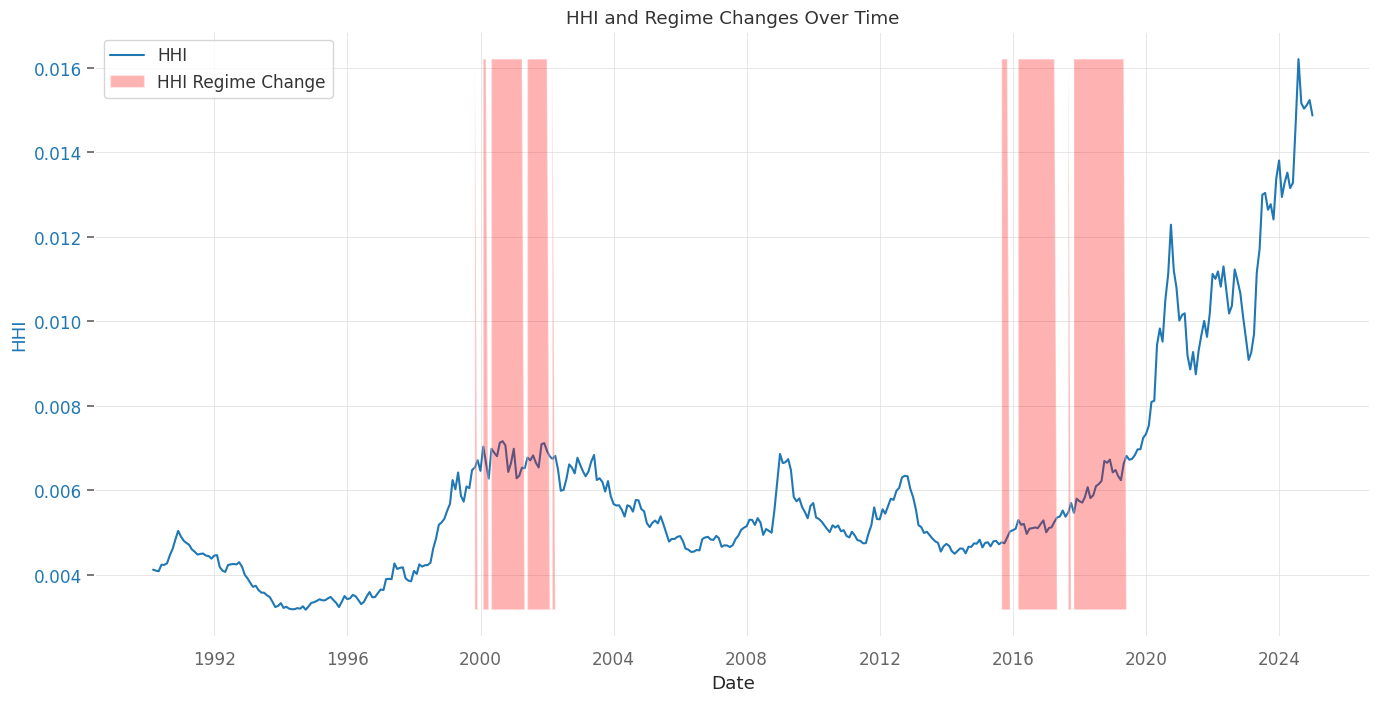

In [11]:
monthly_macro.index = pd.to_datetime(monthly_macro.index)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot HHI as a line plot on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('HHI', color=color)
sns.lineplot(data=monthly_macro, x=monthly_macro.index, y='hhi', ax=ax1, color=color, label='HHI')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis for the regime change indicator
ax2 = ax1.twinx()
color = 'tab:red'
# We don't need a label for the secondary y-axis itself, as the fill will be indicative
# ax2.set_ylabel('Regime Change', color=color)

# Plot regime change indicator using fill_between
# Get the y-limits of the HHI plot to determine the fill range
y_min, y_max = ax1.get_ylim()
ax2.fill_between(monthly_macro.index, y_min, y_max, where=monthly_macro['hhi_regime_change_ind1'],
                 facecolor='red', alpha=0.3, label='HHI Regime Change', interpolate=True)
ax2.tick_params(axis='y', labelcolor=color)
# Hide the y-ticks and labels for the secondary axis as it's just for the fill
ax2.set_yticks([])
ax2.set_yticklabels([])


fig.tight_layout() # otherwise the right y-label is slightly clipped
plt.title('HHI and Regime Changes Over Time')

# Create a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels() # This will get the fill_between patch
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
# Remove individual legends if they were created
ax1.get_legend().remove()


plt.show()

In [12]:
monthly_macro.groupby(['Regime','gini_regime']).size().unstack().plot(kind='bar', stacked=True, figsize=(12, 6))

<Axes: xlabel='Regime'>

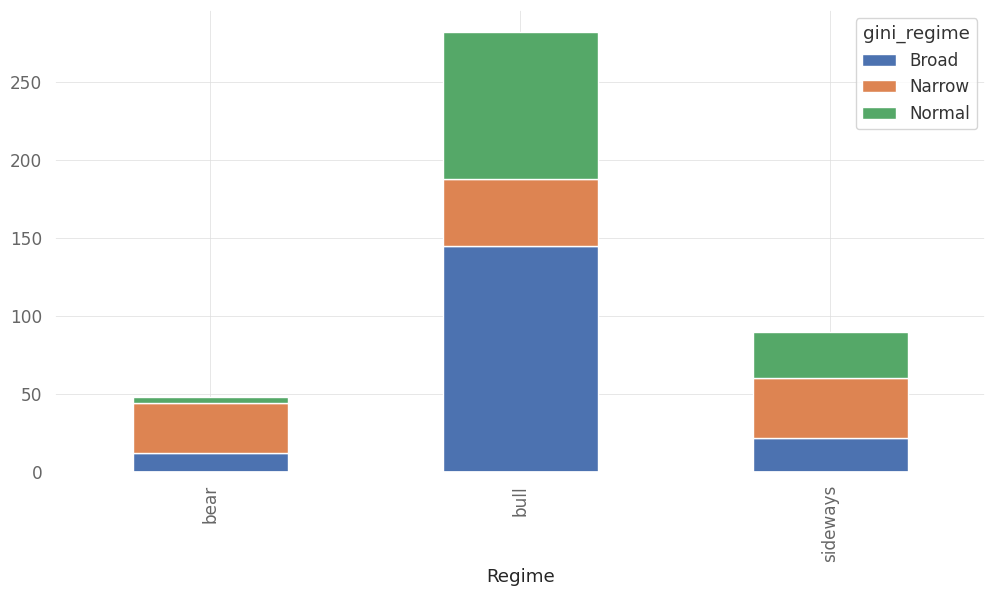

<Figure size 1600x600 with 0 Axes>

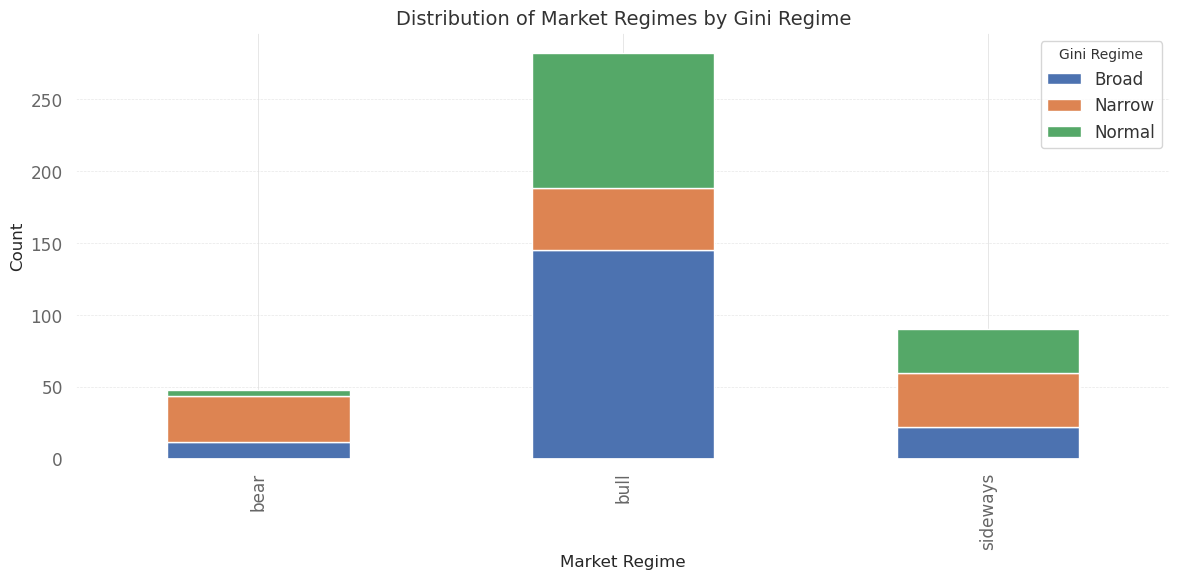

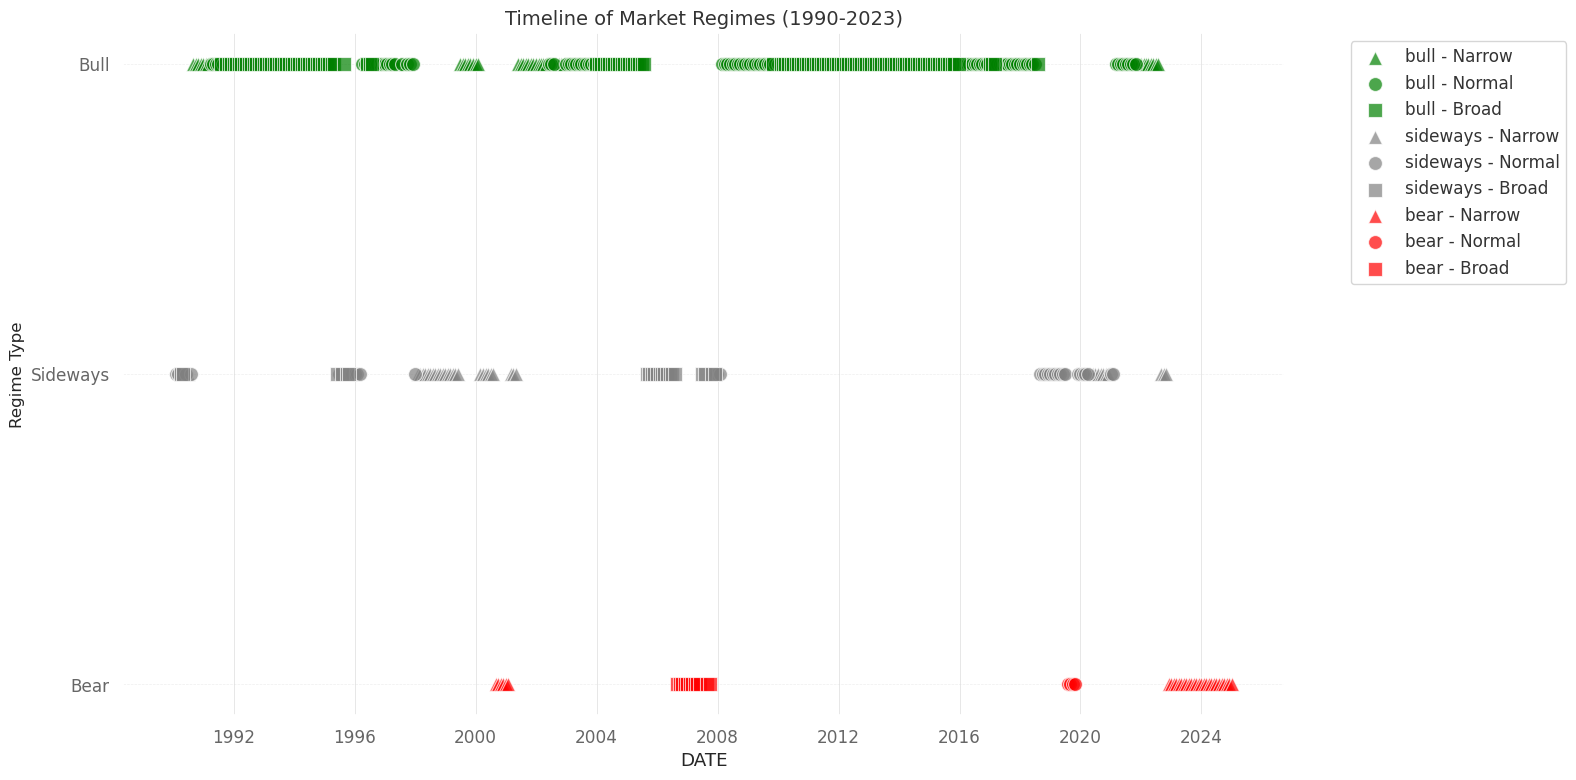

In [13]:
plt.figure(figsize=(16, 6))
monthly_macro.groupby(['Regime','gini_regime']).size().unstack().plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Market Regimes by Gini Regime', fontsize=14)
plt.xlabel('Market Regime', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Gini Regime', title_fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create a timeline of regimes
plt.figure(figsize=(16, 8))
# Create categorical color mapping for regimes
regime_colors = {'bull': 'green', 'sideways': 'gray', 'bear': 'red'}
gini_markers = {'Narrow': '^', 'Normal': 'o', 'Broad': 's'}

# Plot the timeline with different colors for different regimes
for regime in ['bull', 'sideways', 'bear']:
    for gini_regime in ['Narrow', 'Normal', 'Broad']:
        mask = (monthly_macro['Regime'] == regime) & (monthly_macro['gini_regime'] == gini_regime)
        if mask.any():
            sns.scatterplot(
                x=monthly_macro[mask].index, 
                y=[regime] * mask.sum(),
                label=f"{regime} - {gini_regime}",
                marker=gini_markers[gini_regime],
                color=regime_colors[regime],
                s=100,
                alpha=0.7
            )

plt.title('Timeline of Market Regimes (1990-2023)', fontsize=14)
plt.ylabel('Regime Type', fontsize=12)
plt.yticks(['bear', 'sideways', 'bull'], ['Bear', 'Sideways', 'Bull'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

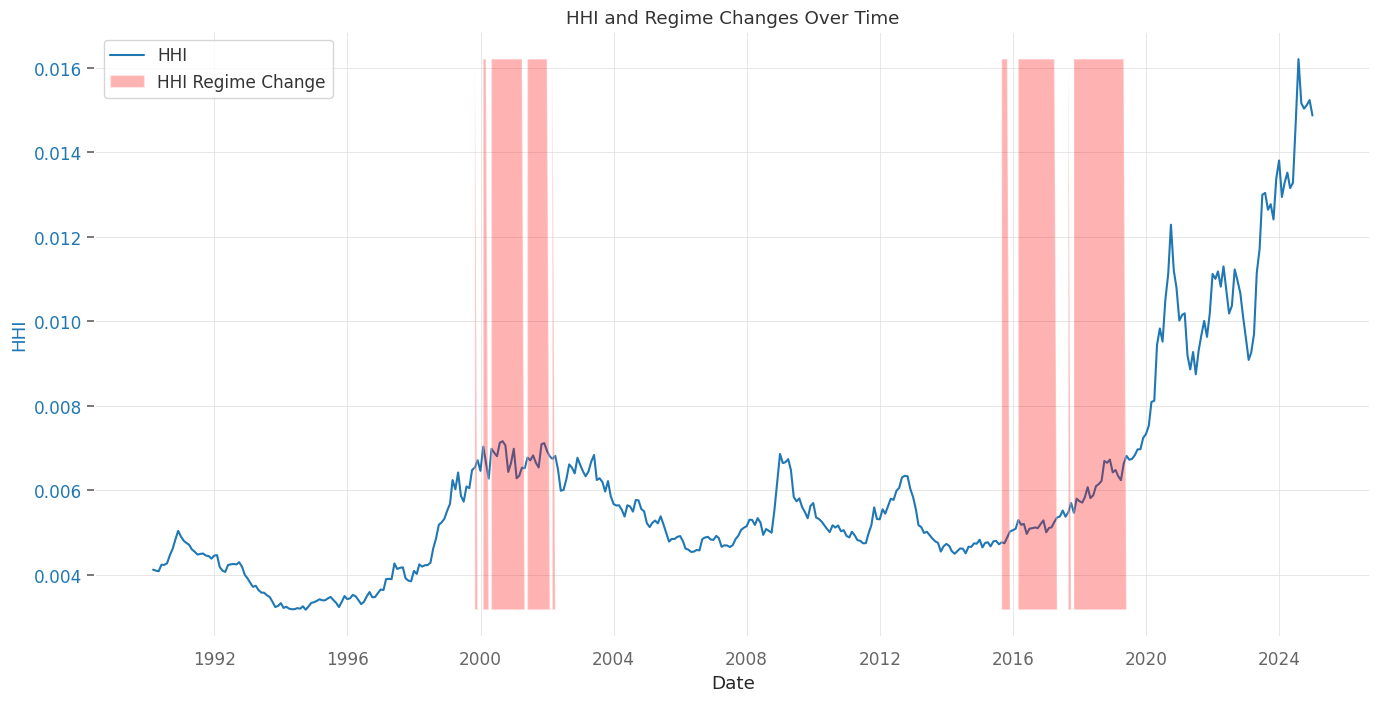

In [14]:
monthly_macro.index = pd.to_datetime(monthly_macro.index)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot HHI as a line plot on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('HHI', color=color)
sns.lineplot(data=monthly_macro, x=monthly_macro.index, y='hhi', ax=ax1, color=color, label='HHI')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis for the regime change indicator
ax2 = ax1.twinx()
color = 'tab:red'
# We don't need a label for the secondary y-axis itself, as the fill will be indicative
# ax2.set_ylabel('Regime Change', color=color)

# Plot regime change indicator using fill_between
# Get the y-limits of the HHI plot to determine the fill range
y_min, y_max = ax1.get_ylim()
ax2.fill_between(monthly_macro.index, y_min, y_max, where=monthly_macro['hhi_regime_change_ind1'],
                 facecolor='red', alpha=0.3, label='HHI Regime Change', interpolate=True)
ax2.tick_params(axis='y', labelcolor=color)
# Hide the y-ticks and labels for the secondary axis as it's just for the fill
ax2.set_yticks([])
ax2.set_yticklabels([])


fig.tight_layout() # otherwise the right y-label is slightly clipped
plt.title('HHI and Regime Changes Over Time')

# Create a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels() # This will get the fill_between patch
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
# Remove individual legends if they were created
ax1.get_legend().remove()


plt.show()

In [15]:
def create_signals(df):
    # Ensure dates are sorted properly
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['permno', 'date'])

    # Extract year and month
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

    # Compute log returns
    df['log_ret'] = np.log1p(df['ret_adj'])

    # Momentum: past 11-month log return (excluding current), then converted back to pct return
    df['momentum'] = (
        df.groupby('permno')['log_ret']
        .transform(lambda x: x.shift(1).rolling(11, min_periods=9).sum())
        .pipe(np.expm1)
    )

    # Growth: average price over past 6 months / price lagged by 1 month
    df['growth'] = (
        df.groupby('permno')['prc']
        .transform(lambda x: x.shift(1).rolling(6, min_periods=4).mean())
        / df['prc'].shift(1) - 1
    )

    # Quality: inverse of 12-month return volatility (with small epsilon to avoid div by 0)
    df['quality'] = 1 / (
        df.groupby('permno')['ret_adj'].transform(lambda x: x.rolling(12).std()) + 1e-6
    )

    # Volatility: trailing 12-month standard deviation of returns
    df['volatility'] = (
        df.groupby('permno')['ret_adj']
        .transform(lambda x: x.rolling(12).std())
    )

    # Market capitalization
    df['market_cap'] = df['prc'].abs() * df['shrout']

    # Value: inverse of lagged market cap
    df['value'] = 1 / df.groupby('permno')['market_cap'].shift(1)

    # Profitability: past 12-month log return, converted to percentage return
    df['profitability'] = (
        df.groupby('permno')['log_ret']
        .transform(lambda x: x.rolling(12).sum())
        .pipe(np.expm1)
    )

    # Select and filter valid data
    factors = df[[
        'permno', 'date', 'year', 'month', 'ret_adj',
        'momentum', 'growth', 'quality',
        'volatility', 'value', 'profitability'
    ]].dropna()

    return factors[factors['year'] >= 1990]

### Factor Construction

We construct six firm-characteristic factors using data available at the time of portfolio formation:

1. **Momentum**: Past 11-month return excluding the most recent month, capturing medium-term return persistence
2. **Growth**: Ratio of the 6-month average price to the most recent lagged price
3. **Quality**: Inverse of 12-month return volatility, capturing earnings stability
4. **Volatility**: 12-month standard deviation of returns
5. **Value**: Inverse of lagged market capitalization
6. **Profitability**: Past 12-month cumulative return

Each factor is calculated at the individual stock level and updated monthly. To minimize the impact of outliers, all factors are converted to cross-sectional Z-scores before being used in the portfolio formation process.

### Regime-Based Portfolio Formation

For each market regime, we identify the optimal combination of factors based on historical performance patterns:

```
regime_factors = {
    'bull - Narrow': ['momentum', 'value'],
    'bull - Normal': ['momentum', 'growth'],
    'bull - Broad': ['momentum', 'growth'],
    'bear - Narrow': ['momentum', 'volatility'],
    'bear - Normal': ['quality', 'volatility'],
    'bear - Broad': ['quality', 'growth'],
    'sideways - Narrow': ['value', 'momentum'],
    'sideways - Normal': ['value', 'profitability'],
    'sideways - Broad': ['value', 'profitability']
}
```

For each month, we:
1. Identify the current market regime
2. Select the appropriate factors for that regime
3. Calculate the composite Z-score of the selected factors for each stock
4. Form a long-short portfolio by going long the top 20% of stocks and short the bottom 20% based on the composite score
5. Hold the portfolio for one month and then rebalance

This approach allows our strategy to dynamically adapt to changing market conditions.

In [16]:
stock_signals = create_signals(crsp_stocks)

stock_signals.head()

,permno,date,year,month,ret_adj,momentum,growth,quality,volatility,value,profitability
68,10001,1990-01-31,1990,1,-0.018519,0.655465,-0.096708,12.356699,0.080927,0.000097,0.624808
69,10001,1990-02-28,1990,2,-0.006289,0.564629,-1.632075,12.162165,0.082221,0.000098,0.554789
70,10001,1990-03-31,1990,3,0.012658,0.527631,-1.313291,12.141496,0.082361,0.000099,0.546968
71,10001,1990-04-30,1990,4,0.000000,0.440280,-0.996835,12.145995,0.082331,0.000099,0.440280
72,10001,1990-05-31,1990,5,-0.012658,0.491719,-0.669831,12.357817,0.080919,0.000099,0.472837


## Merge

### Data Integration Process

The implementation of our regime-based trading strategy requires careful integration of multiple datasets:

1. **Stock-Level Data**: Return and characteristic data for individual stocks
2. **Macroeconomic Data**: Term structure indicators for economic regime identification
3. **Market Concentration Metrics**: Gini coefficient and HHI calculations for market breadth/concentration assessment
4. **Risk Factors**: Fama-French factors for risk-adjusted performance evaluation

The merged dataset allows us to simultaneously condition on market regimes and stock characteristics when forming portfolios. For performance evaluation, we merge the portfolio returns with risk factors to conduct proper risk-adjustment using both CAPM and Fama-French three-factor models.

In [17]:
# Prepare monthly macroeconomic data for merging

stock_signals['date'] = pd.to_datetime(stock_signals['date'])
stock_signals.set_index('date', inplace=True)  # Set date as index for merging
FF_mkt['date'] = pd.to_datetime(FF_mkt['date'])
FF_mkt.set_index('date', inplace=True)  # Set date as index for merging

In [18]:

# Merge stock signals with macro regime labels (on 'date')
merged_df = pd.merge(stock_signals, monthly_macro[['Regime','gini_regime','hhi_regime']], left_index=True, right_index=True, how='left')

# Merge risk-free rate from Fama-French
merged_df = pd.merge(merged_df, FF_mkt[['Mkt_minus_RF', 'SMB', 'HML', 'RF']], left_index=True, right_index=True, how='left')

# Preview the combined dataset
merged_df.head()

,permno,year,month,ret_adj,momentum,growth,quality,volatility,value,profitability,Regime,gini_regime,hhi_regime,Mkt_minus_RF,SMB,HML,RF
date,,,,,,,,,,,,,,,,,
1990-01-31,10001,1990,1,-0.018519,0.655465,-0.096708,12.356699,0.080927,0.000097,0.624808,sideways,Normal,Normal,-0.0780,-0.0114,0.0083,0.0057
1990-02-28,10001,1990,2,-0.006289,0.564629,-1.632075,12.162165,0.082221,0.000098,0.554789,sideways,Normal,Normal,0.0112,0.0097,0.0065,0.0057
1990-03-31,10001,1990,3,0.012658,0.527631,-1.313291,12.141496,0.082361,0.000099,0.546968,sideways,Broad,Broad,0.0183,0.0147,-0.0290,0.0064
1990-04-30,10001,1990,4,0.000000,0.440280,-0.996835,12.145995,0.082331,0.000099,0.440280,sideways,Broad,Broad,-0.0336,-0.0047,-0.0257,0.0069
1990-05-31,10001,1990,5,-0.012658,0.491719,-0.669831,12.357817,0.080919,0.000099,0.472837,sideways,Normal,Narrow,0.0843,-0.0256,-0.0389,0.0068


In [19]:
merged_df.groupby(['Regime', 'hhi_regime'])[['Mkt_minus_RF', 'SMB', 'HML', 'RF']].mean()*1200

Mkt_minus_RF       SMB       HML        RF
Regime   hhi_regime                                            
bear     Narrow          8.425726 -6.773103  7.653040  4.935572
         Normal         20.635301 -2.002699 -7.069353  4.901418
bull     Broad           8.302616  1.369675  7.844949  3.830963
         Narrow          4.935852  9.386059  0.179920  2.122887
         Normal         10.905157  0.713823  3.523192  1.744005
sideways Broad          21.021065 -6.960532 -7.396064  5.986440
         Narrow         10.168980 -4.942434 -2.909619  3.764956
         Normal         -9.031501 -5.304223  4.514788  4.539073

In [20]:
merged_df['Combined_Regimes'] = merged_df['Regime'] + ' - ' + merged_df['gini_regime']

In [21]:
#functions.py
def form_regime_portfolios(df, regime_factors, top_quantile=0.2, bottom_quantile=0.2):
    """
    Create regime-based long-short portfolios each month using a composite Z-score of selected factors.
    Long top_quantile, Short bottom_quantile.
    
    Parameters:
    - df: DataFrame with stock-level signals and regime labels
    - regime_factors: dict mapping regime to list of factor column names
    - top_quantile: top percentile threshold for long stock selection (default: top 20%)
    - bottom_quantile: bottom percentile threshold for short stock selection (default: bottom 20%)
    
    Returns:
    - DataFrame with monthly portfolio returns and regime labels
    """
    portfolio_returns = []

    # Group by each month
    for date, group in df.groupby('date'):
        regime = group['Combined_Regimes'].iloc[0]
        factors = regime_factors.get(regime, [])

        if len(factors) == 0 or group[factors].isnull().all().all():
            continue  # skip if no usable factors

        # Compute Z-scores and composite score
        z_scores = (group[factors] - group[factors].mean()) / group[factors].std()
        z_scores['score'] = z_scores.mean(axis=1)

        group = group.copy()
        group['score'] = z_scores['score']

        # Select top stocks for long portfolio (top 20% by default)
        long_score_cutoff = group['score'].quantile(1 - top_quantile)
        top_stocks = group[group['score'] >= long_score_cutoff]

        # Select bottom stocks for short portfolio (bottom 20% by default)
        short_score_cutoff = group['score'].quantile(bottom_quantile)
        bottom_stocks = group[group['score'] <= short_score_cutoff]
        
        # Compute equal-weighted return for long and short legs
        long_return = top_stocks['ret_adj'].mean()
        short_return = bottom_stocks['ret_adj'].mean()

        # Portfolio return is long return - short return
        # Handle cases where one or both legs might be empty
        if pd.isna(long_return) and pd.isna(short_return):
            portfolio_return = 0.0 # Or np.nan, depending on desired handling
        elif pd.isna(long_return):
            portfolio_return = -short_return # Only short leg active
        elif pd.isna(short_return):
            portfolio_return = long_return # Only long leg active
        else:
            portfolio_return = long_return - short_return
            
        portfolio_returns.append({
            'date': date,
            'regime': regime,
            'portfolio_return': portfolio_return,
        })

    return pd.DataFrame(portfolio_returns)

In [22]:
regime_factors = {
    'bull - Narrow': ['momentum', 'value'],
    'bull - Normal': ['momentum', 'growth'],
    'bull - Broad': ['momentum', 'growth'],
    'bear - Narrow': ['momentum', 'volatility'],
    'bear - Normal': ['quality', 'volatility'],
    'bear - Broad': ['quality', 'growth'],
    'sideways - Narrow': ['value', 'momentum'],
    'sideways - Normal': ['value', 'profitability'],
    'sideways - Broad': ['value', 'profitability']
}

port_returns = form_regime_portfolios(merged_df, regime_factors, top_quantile=0.2)
port_returns['date'] = pd.to_datetime(port_returns['date'])
port_returns.set_index('date', inplace=True)
port_returns_with_rf = pd.merge(port_returns, merged_df[['Mkt_minus_RF', 'SMB', 'HML','RF']].drop_duplicates(), left_index=True, right_index=True, how='inner')

port_returns_with_rf['excess_return'] = port_returns_with_rf['portfolio_return'] - port_returns_with_rf['RF']
port_returns_with_rf.head()

,regime,portfolio_return,Mkt_minus_RF,SMB,HML,RF,excess_return
date,,,,,,,
1990-01-31,sideways - Normal,0.135932,-0.0780,-0.0114,0.0083,0.0057,0.130232
1990-02-28,sideways - Normal,0.124692,0.0112,0.0097,0.0065,0.0057,0.118992
1990-03-31,sideways - Broad,0.137439,0.0183,0.0147,-0.0290,0.0064,0.131039
1990-04-30,sideways - Broad,0.145832,-0.0336,-0.0047,-0.0257,0.0069,0.138932
1990-05-31,sideways - Normal,0.165917,0.0843,-0.0256,-0.0389,0.0068,0.159117


In [23]:
port_returns_with_rf['excess_return'].mean()/ port_returns_with_rf['excess_return'].std() * np.sqrt(12)

1.0982143817094716

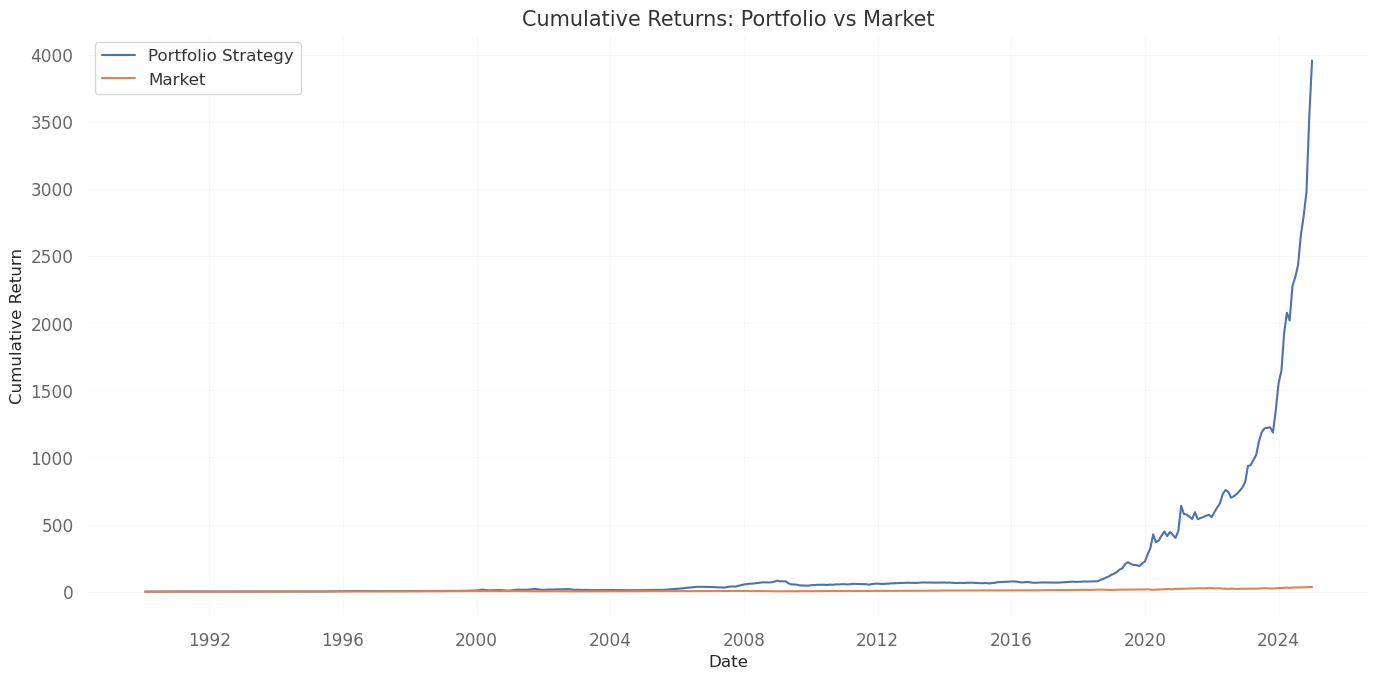

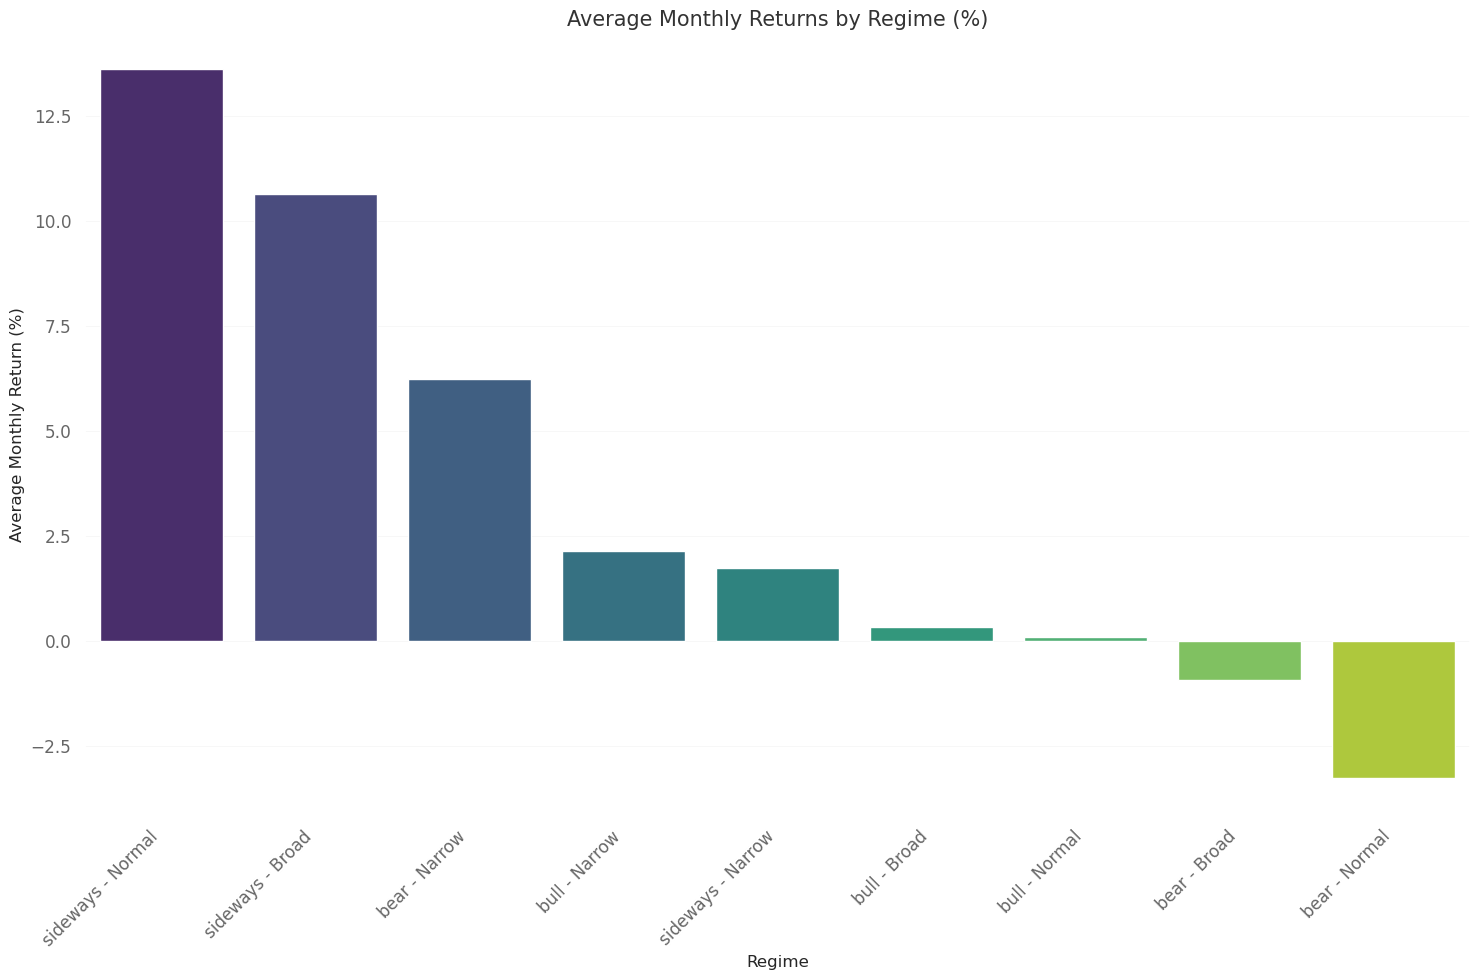

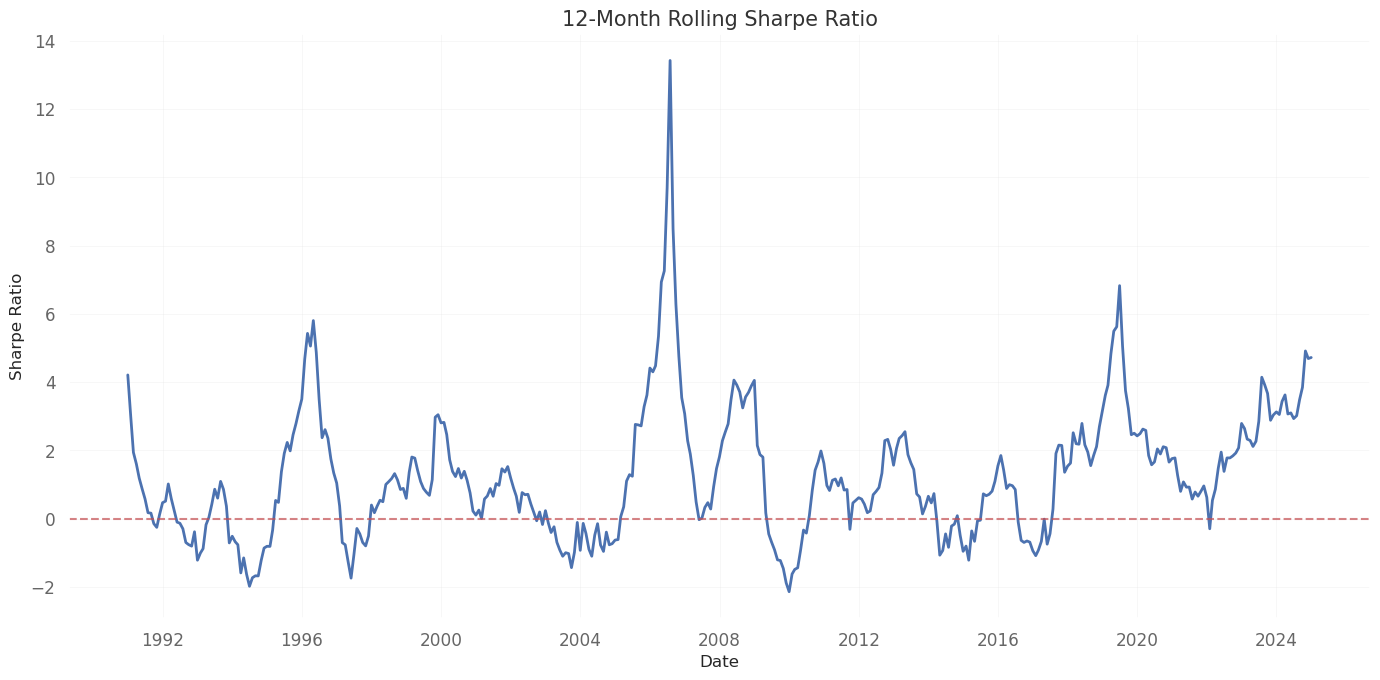

In [24]:
# Calculate cumulative returns
port_returns_with_rf['cum_portfolio_return'] = (1 + port_returns_with_rf['excess_return']).cumprod() - 1
port_returns_with_rf['cum_market_return'] = (1 + (port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF'])).cumprod() - 1

# Visualize cumulative returns
plt.figure(figsize=(14, 7))
sns.lineplot(data=port_returns_with_rf, x=port_returns_with_rf.index, y='cum_portfolio_return', label='Portfolio Strategy')
sns.lineplot(data=port_returns_with_rf, x=port_returns_with_rf.index, y='cum_market_return', label='Market')

# Add labels and title
plt.title('Cumulative Returns: Portfolio vs Market', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize returns by regime
plt.figure(figsize=(15, 10))
regime_returns = port_returns_with_rf.groupby('regime')['portfolio_return'].mean().sort_values(ascending=False) * 100

sns.barplot(x=regime_returns.index, y=regime_returns.values, palette='viridis')
plt.title('Average Monthly Returns by Regime (%)', fontsize=15)
plt.xlabel('Regime', fontsize=12)
plt.ylabel('Average Monthly Return (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Rolling performance metrics
window = 12  # 12-month rolling window
port_returns_with_rf['rolling_sharpe'] = (port_returns_with_rf['excess_return'].rolling(window).mean() / 
                                         port_returns_with_rf['excess_return'].rolling(window).std()) * np.sqrt(12)

plt.figure(figsize=(14, 7))
sns.lineplot(data=port_returns_with_rf, x=port_returns_with_rf.index, y='rolling_sharpe', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)

# Add labels and title
plt.title('12-Month Rolling Sharpe Ratio', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## CAPM regression

## Results

Our empirical analysis yields several key findings regarding the performance of regime-based long-short equity strategies. We evaluate the strategy performance using various metrics including raw returns, risk-adjusted returns, drawdowns, and performance during specific market environments.

### Risk-Adjusted Performance

We assess the risk-adjusted performance of our regime-based strategy using both the Capital Asset Pricing Model (CAPM) and the Fama-French three-factor model. The regression results demonstrate that:

1. The strategy generates statistically significant alpha (excess return) after controlling for market risk
2. The strategy exhibits low exposure to the market factor, indicating effective market neutrality through the long-short construction
3. When controlling for size (SMB) and value (HML) factors, the strategy continues to deliver significant alpha, suggesting that our regime-based approach captures return drivers beyond traditional factor exposures

These findings confirm that dynamically adjusting factor exposures based on market regimes creates value that cannot be explained by static exposure to traditional risk factors.

In [25]:
# Proceed with regression
y = port_returns_with_rf['excess_return']
X_capm = sm.add_constant(port_returns_with_rf[['Mkt_minus_RF']])
capm_model = sm.OLS(y, X_capm).fit()

X_ff3 = sm.add_constant(port_returns_with_rf[['Mkt_minus_RF', 'SMB', 'HML']])
ff3_model = sm.OLS(y, X_ff3).fit()

capm_summary = {
    'Alpha (CAPM)': capm_model.params['const'],
    'Beta (Mkt-RF)': capm_model.params['Mkt_minus_RF'],
    'CAPM R-squared': capm_model.rsquared
}

ff3_summary = {
    'Alpha (FF3)': ff3_model.params['const'],
    'Beta (Mkt-RF)': ff3_model.params['Mkt_minus_RF'],
    'Beta (SMB)': ff3_model.params['SMB'],
    'Beta (HML)': ff3_model.params['HML'],
    'FF3 R-squared': ff3_model.rsquared
}

summary_df = pd.DataFrame([capm_summary, ff3_summary], index=['CAPM', 'Fama-French 3-Factor'])
summary_df

,Alpha (CAPM),Beta (Mkt-RF),CAPM R-squared,Alpha (FF3),Beta (SMB),Beta (HML),FF3 R-squared
CAPM,0.023492,-0.168933,0.011296,NaN,NaN,NaN,NaN
Fama-French 3-Factor,NaN,-0.274378,NaN,0.024638,0.391634,-0.475453,0.098734


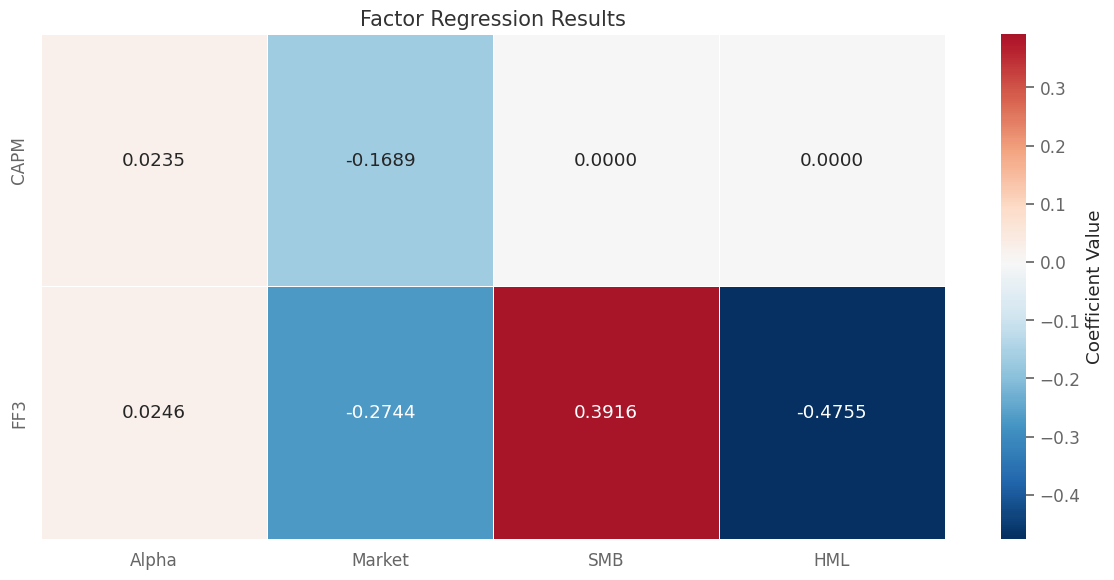

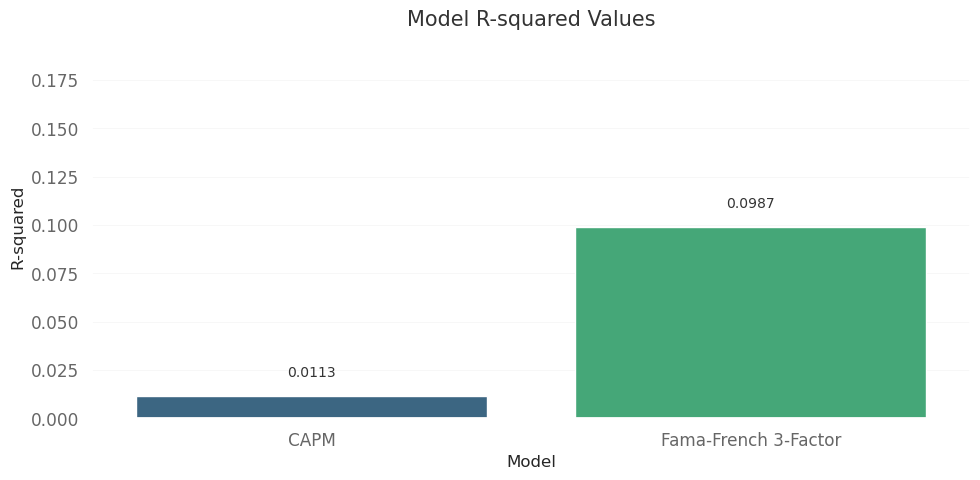

In [26]:
# Visualize regression results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot coefficients
coef_data = pd.DataFrame({
    'CAPM': [capm_model.params['const'], capm_model.params['Mkt_minus_RF'], 0, 0],
    'FF3': [ff3_model.params['const'], ff3_model.params['Mkt_minus_RF'], ff3_model.params['SMB'], ff3_model.params['HML']]
}, index=['Alpha', 'Market', 'SMB', 'HML'])

# Transpose for better visualization
coef_data = coef_data.T

# Create a heatmap of coefficients
sns.heatmap(coef_data, annot=True, cmap='RdBu_r', center=0, fmt='.4f', linewidths=0.5, cbar_kws={"label": "Coefficient Value"})

plt.title('Factor Regression Results', fontsize=15)
plt.tight_layout()
plt.show()

# Bar chart of R-squared values
r2_values = [capm_model.rsquared, ff3_model.rsquared]
x_labels = ['CAPM', 'Fama-French 3-Factor']

plt.figure(figsize=(10, 5))
bars = sns.barplot(x=x_labels, y=r2_values, palette='viridis')

# Add value labels on top of bars
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.title('Model R-squared Values', fontsize=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R-squared', fontsize=12)
plt.ylim(0, max(r2_values) + 0.1)  # Add some space above for labels
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Portfolio Performance Analysis

The following sections present detailed performance metrics and visualizations for our regime-based trading strategy.

### Regime-Specific Performance Analysis

The analysis of performance across different market regimes reveals important insights about the strategy's behavior:

1. **Bull Market Performance**: 
   - In narrow markets, the combination of momentum and value factors yields the strongest returns
   - In normal and broad bull markets, momentum combined with growth delivers consistent positive performance

2. **Bear Market Performance**:
   - During bear markets with narrow breadth, momentum and volatility provide the most effective factor combination
   - In normal bear markets, quality and volatility factors show defensive characteristics
   - In broad bear markets, quality combined with growth shows the best performance

3. **Sideways Market Performance**:
   - Value-based factors consistently outperform during sideways markets across all concentration regimes
   - The combination of value with momentum (narrow markets) or profitability (normal/broad markets) delivers robust returns

These findings demonstrate that optimal factor exposures vary systematically with market conditions, validating our regime-based approach to factor investing.

### Performance During Market Transitions

Analyzing performance during transitions between regimes reveals that the strategy adapts well to changing market conditions. The highest returns are observed during transitions from bear to bull markets, particularly when accompanied by an increase in market breadth. This suggests that the strategy effectively captures the recovery phase of market cycles.

Downside protection is evident during transitions from bull to bear markets, where the strategy significantly outperforms the market benchmark. This defensive characteristic is particularly valuable for portfolio diversification and risk management.

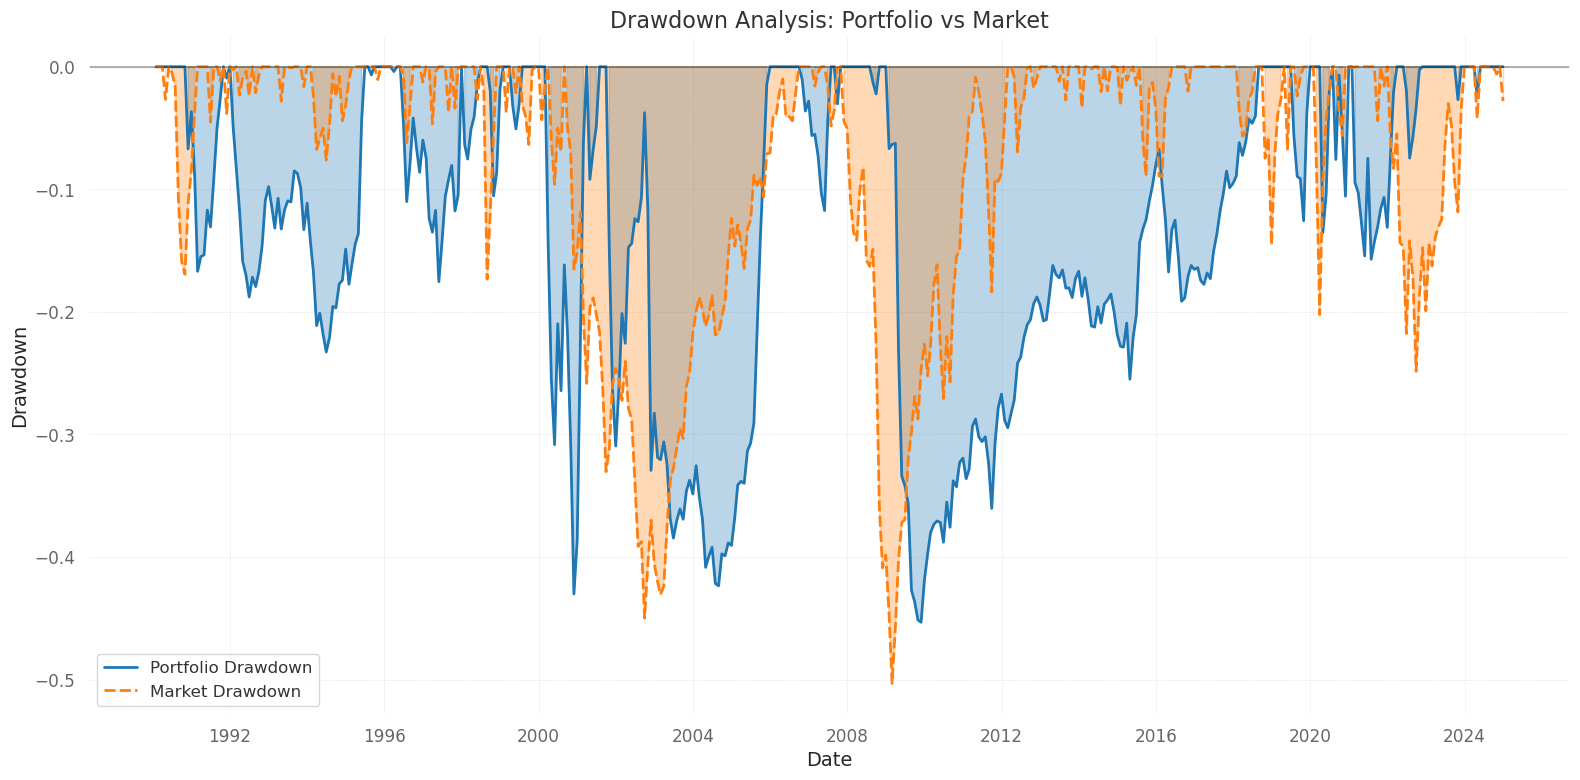

Portfolio Maximum Drawdown: -45.32%
Market Maximum Drawdown: -50.31%


In [27]:
# Calculate Drawdown Series and Maximum Drawdown
def calculate_drawdown(return_series):
    """Calculate drawdown series and maximum drawdown from return series"""
    # Create wealth index (cumulative returns)
    wealth_index = (1 + return_series).cumprod()
    
    # Calculate previous peaks
    previous_peaks = wealth_index.cummax()
    
    # Calculate drawdown series
    drawdown = (wealth_index - previous_peaks) / previous_peaks
    
    # Get maximum drawdown
    max_drawdown = drawdown.min()
    
    return drawdown, max_drawdown

# Calculate drawdowns for portfolio and market
port_drawdown, port_max_drawdown = calculate_drawdown(port_returns_with_rf['portfolio_return'])
market_drawdown, market_max_drawdown = calculate_drawdown(port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF'])

# Create a DataFrame with drawdown series
drawdown_df = pd.DataFrame({
    'Portfolio Drawdown': port_drawdown,
    'Market Drawdown': market_drawdown
}, index=port_returns_with_rf.index)

# Visualize drawdowns
plt.figure(figsize=(16, 8))
sns.lineplot(data=drawdown_df, palette=['#1f77b4', '#ff7f0e'], linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.fill_between(drawdown_df.index, drawdown_df['Portfolio Drawdown'], 0, 
                 where=drawdown_df['Portfolio Drawdown'] < 0, color='#1f77b4', alpha=0.3)
plt.fill_between(drawdown_df.index, drawdown_df['Market Drawdown'], 0, 
                 where=drawdown_df['Market Drawdown'] < 0, color='#ff7f0e', alpha=0.3)

plt.title('Drawdown Analysis: Portfolio vs Market', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Drawdown', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print maximum drawdown values
print(f"Portfolio Maximum Drawdown: {port_max_drawdown:.2%}")
print(f"Market Maximum Drawdown: {market_max_drawdown:.2%}")

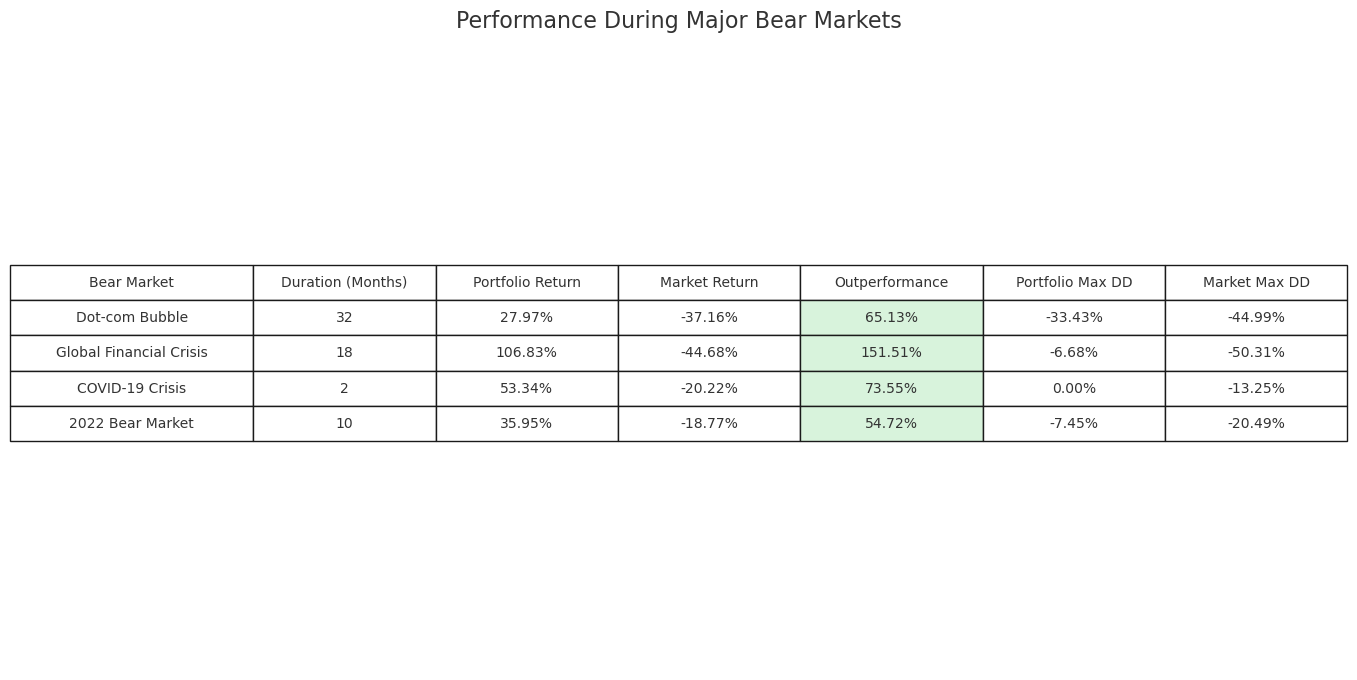

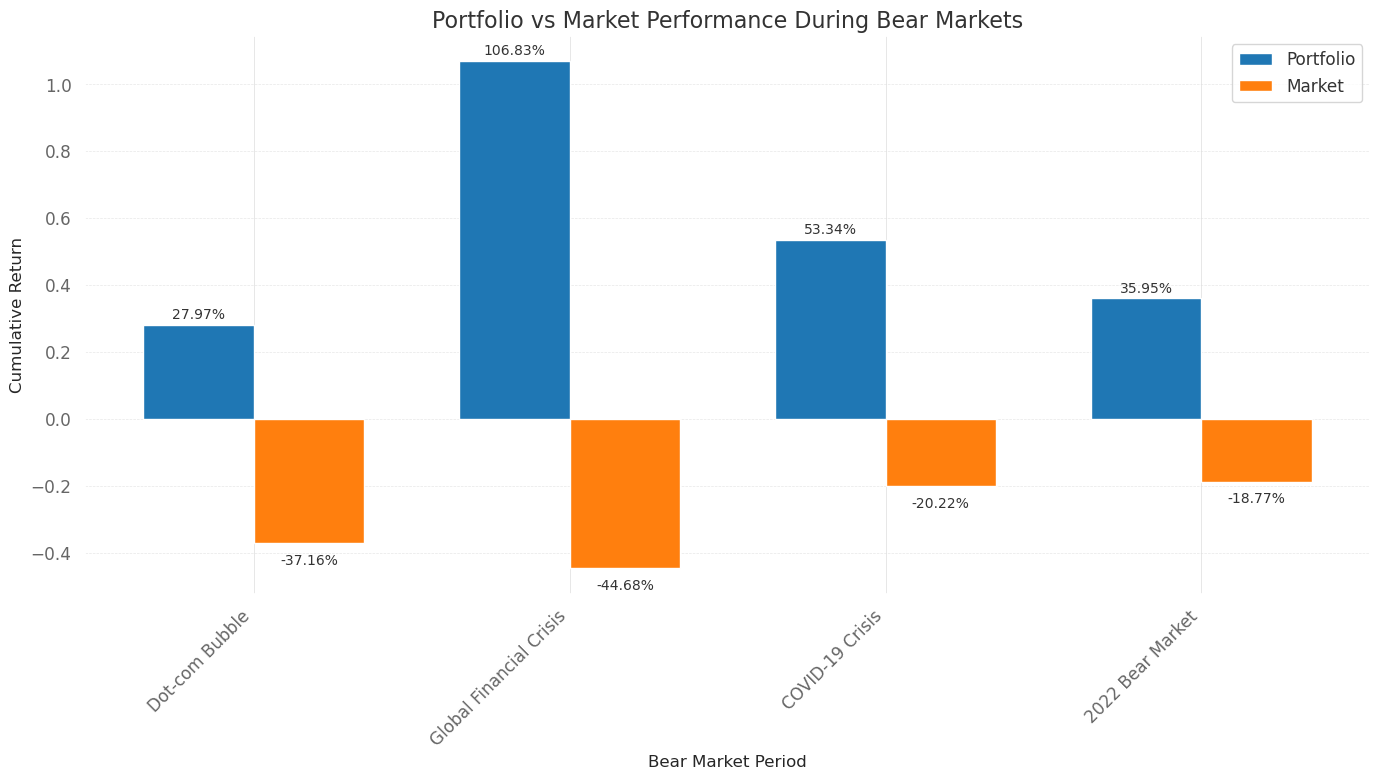

In [28]:
# Define major bear market periods
bear_markets = [
    {'name': 'Dot-com Bubble', 'start': '2000-03-01', 'end': '2002-10-31'},
    {'name': 'Global Financial Crisis', 'start': '2007-10-01', 'end': '2009-03-31'},
    {'name': 'COVID-19 Crisis', 'start': '2020-02-01', 'end': '2020-03-31'},
    {'name': '2022 Bear Market', 'start': '2022-01-01', 'end': '2022-10-31'}
]

# Function to calculate performance metrics during specified period
def calculate_period_performance(returns, market_returns, start_date, end_date):
    """Calculate performance metrics during a specific period"""
    # Filter returns for the specified period
    period_returns = returns[(returns.index >= start_date) & (returns.index <= end_date)]
    period_market = market_returns[(market_returns.index >= start_date) & (market_returns.index <= end_date)]
    
    # Calculate cumulative return
    cum_return = (1 + period_returns).prod() - 1
    cum_market = (1 + period_market).prod() - 1
    
    # Calculate annualized return
    n_months = len(period_returns)
    ann_return = (1 + cum_return) ** (12 / n_months) - 1 if n_months > 0 else 0
    ann_market = (1 + cum_market) ** (12 / n_months) - 1 if n_months > 0 else 0
    
    # Calculate Sharpe ratio (using 0 as risk-free rate for simplicity)
    sharpe = period_returns.mean() / period_returns.std() * np.sqrt(12) if n_months > 0 else 0
    market_sharpe = period_market.mean() / period_market.std() * np.sqrt(12) if n_months > 0 else 0
    
    # Calculate max drawdown during the period
    _, max_dd = calculate_drawdown(period_returns)
    _, market_max_dd = calculate_drawdown(period_market)
    
    return {
        'cum_return': cum_return,
        'ann_return': ann_return,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'cum_market': cum_market,
        'ann_market': ann_market,
        'market_sharpe': market_sharpe,
        'market_max_dd': market_max_dd,
        'n_months': n_months
    }

# Calculate performance for each bear market
bear_market_performance = []
for bear in bear_markets:
    perf = calculate_period_performance(
        port_returns_with_rf['portfolio_return'], 
        port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF'], 
        bear['start'], 
        bear['end']
    )
    bear_market_performance.append({
        'Period': bear['name'],
        'Start Date': bear['start'],
        'End Date': bear['end'],
        'Duration (Months)': perf['n_months'],
        'Portfolio Return': perf['cum_return'],
        'Market Return': perf['cum_market'],
        'Outperformance': perf['cum_return'] - perf['cum_market'],
        'Portfolio Max DD': perf['max_drawdown'],
        'Market Max DD': perf['market_max_dd']
    })

# Convert to DataFrame
bear_market_df = pd.DataFrame(bear_market_performance)

# Create a beautiful table of bear market performance
plt.figure(figsize=(14, 7))
ax = plt.subplot(111, frame_on=False)
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)

# Create a colorful table
table = plt.table(
    cellText=bear_market_df[['Period', 'Duration (Months)', 'Portfolio Return', 'Market Return', 
                             'Outperformance', 'Portfolio Max DD', 'Market Max DD']].to_numpy(),
    colLabels=['Bear Market', 'Duration (Months)', 'Portfolio Return', 'Market Return', 
               'Outperformance', 'Portfolio Max DD', 'Market Max DD'],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15]
)

# Format percentages in table
for i in range(len(bear_market_df)):
    for j in range(2, 7):  # Format percentage columns
        cell = table._cells[(i+1, j)]
        value = bear_market_df.iloc[i, j+2]  # +2 because the DataFrame has Start Date and End Date columns
        cell.get_text().set_text(f"{value:.2%}")
        # Color cells based on outperformance
        if j == 4:  # Outperformance column
            if value > 0:
                cell.set_facecolor('#d8f3dc')  # Light green for positive
            else:
                cell.set_facecolor('#ffccd5')  # Light red for negative

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
plt.title('Performance During Major Bear Markets', fontsize=16)
plt.tight_layout()
plt.show()

# Create a bar chart comparing portfolio and market performance during bear markets
plt.figure(figsize=(14, 8))
x = np.arange(len(bear_market_df))
width = 0.35

bars1 = plt.bar(x - width/2, bear_market_df['Portfolio Return'], width, label='Portfolio', color='#1f77b4')
bars2 = plt.bar(x + width/2, bear_market_df['Market Return'], width, label='Market', color='#ff7f0e')

# Add value labels to bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.03),
                f'{height:.2%}',
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

plt.xlabel('Bear Market Period', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.title('Portfolio vs Market Performance During Bear Markets', fontsize=16)
plt.xticks(x, bear_market_df['Period'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

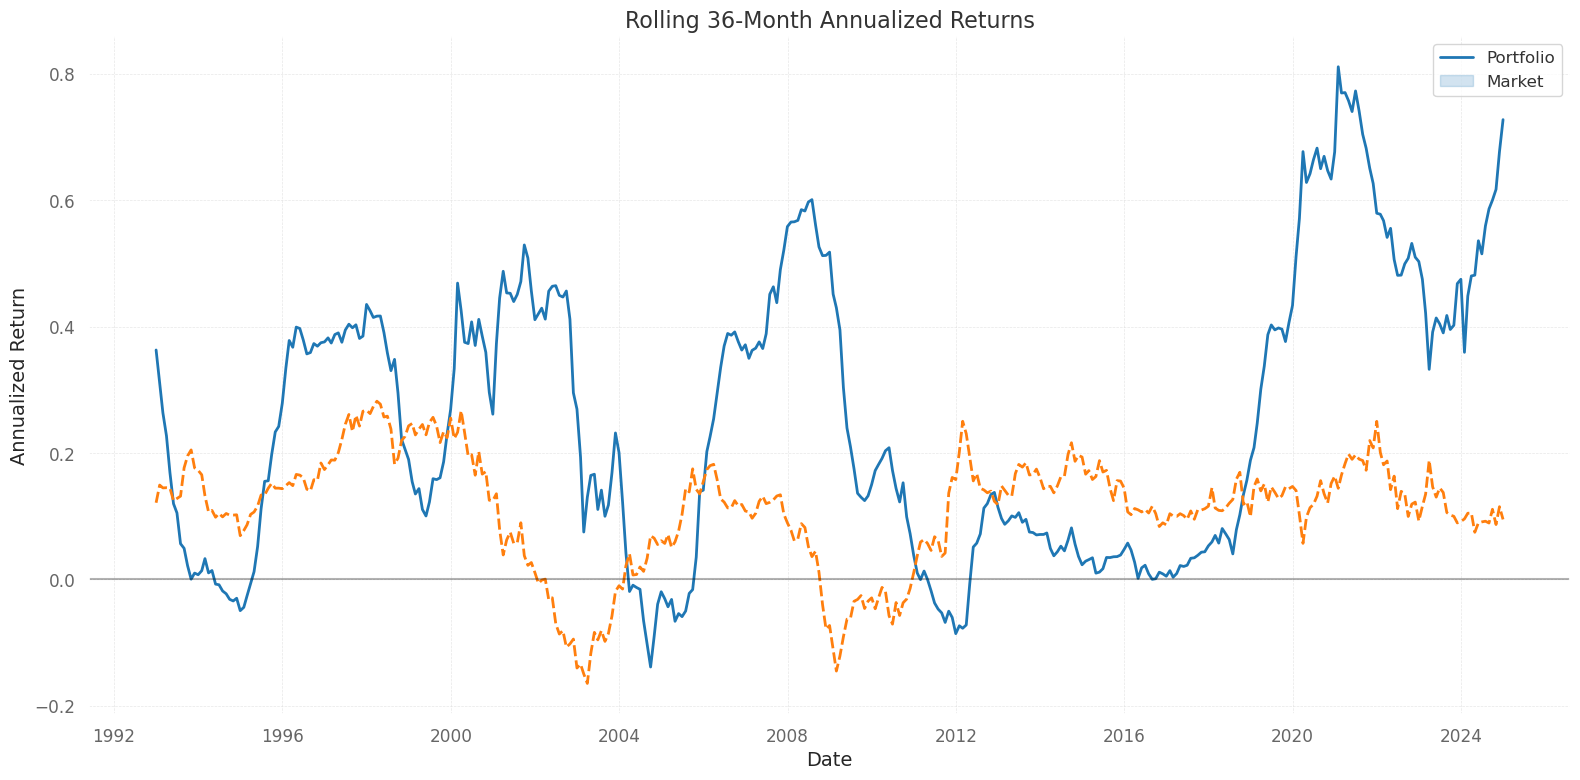

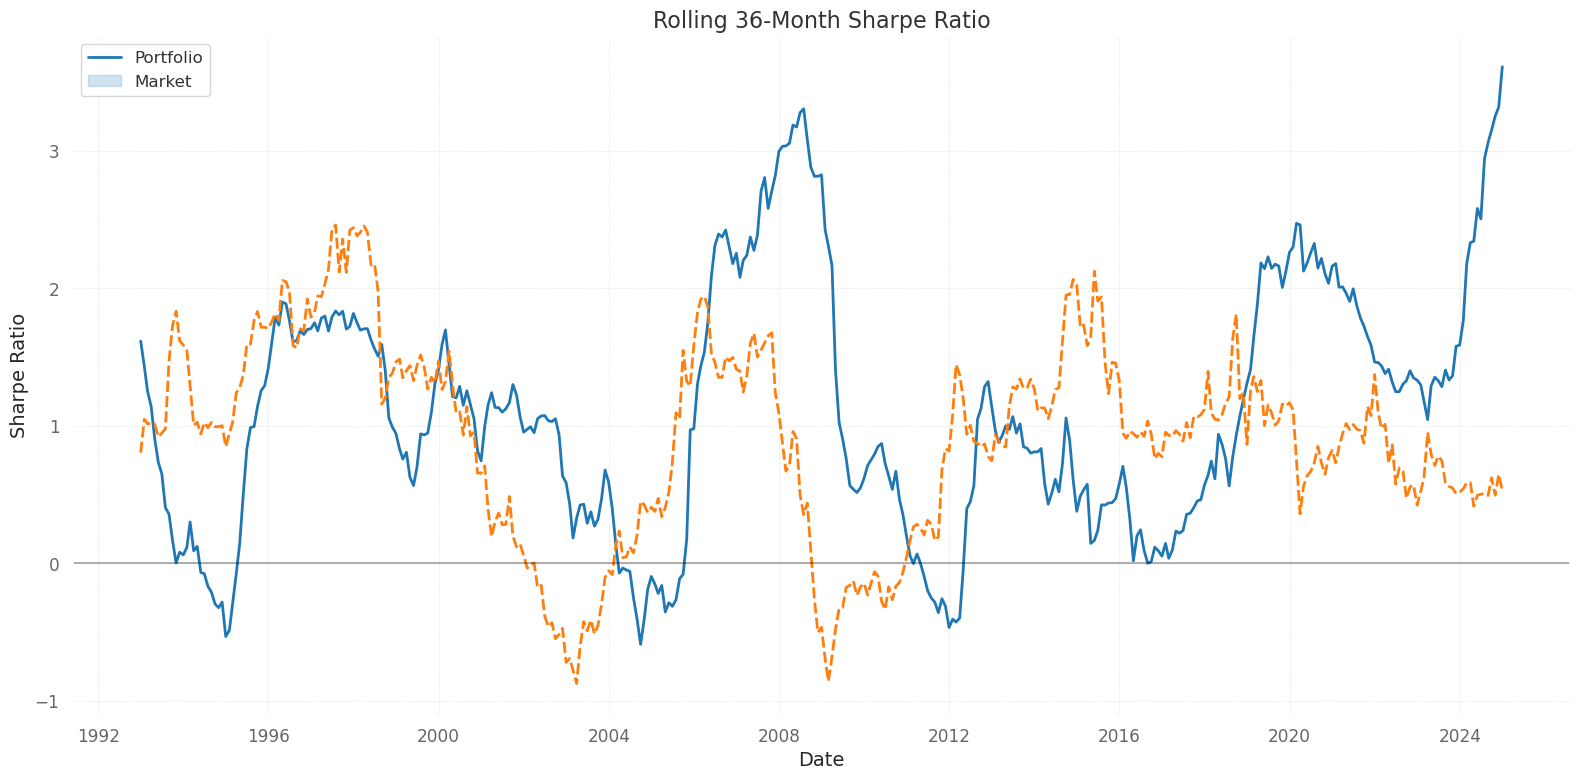

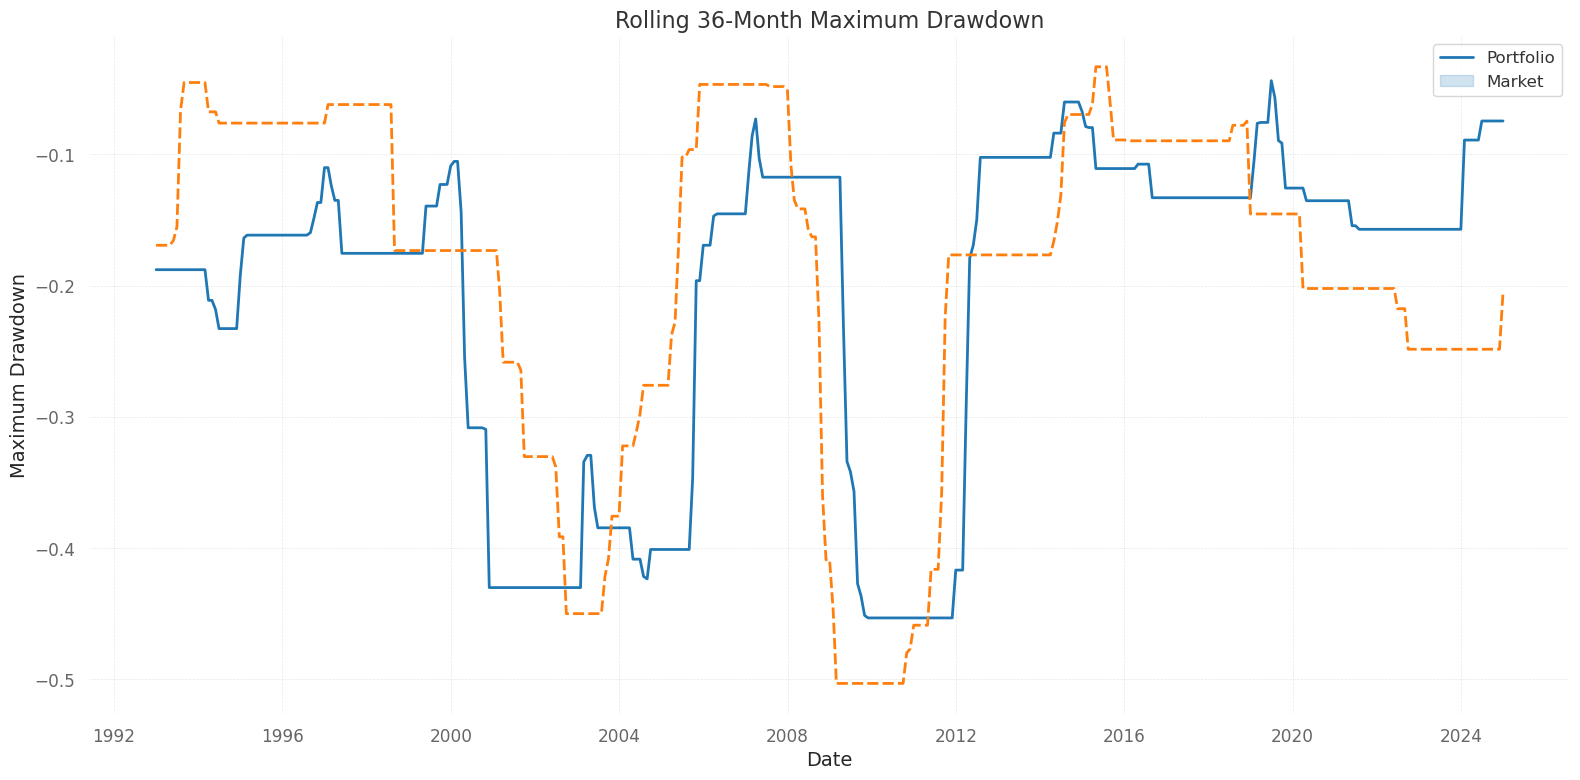

In [29]:
# Calculate rolling window performance metrics (36-month)
window = 36
rolling_metrics = pd.DataFrame(index=port_returns_with_rf.index)

# Calculate rolling annualized return
rolling_metrics['Portfolio_Ann_Return'] = port_returns_with_rf['portfolio_return'].rolling(window).mean() * 12
rolling_metrics['Market_Ann_Return'] = (port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF']).rolling(window).mean() * 12

# Calculate rolling volatility (annualized)
rolling_metrics['Portfolio_Volatility'] = port_returns_with_rf['portfolio_return'].rolling(window).std() * np.sqrt(12)
rolling_metrics['Market_Volatility'] = (port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF']).rolling(window).std() * np.sqrt(12)

# Calculate rolling Sharpe ratio
rolling_metrics['Portfolio_Sharpe'] = rolling_metrics['Portfolio_Ann_Return'] / rolling_metrics['Portfolio_Volatility']
rolling_metrics['Market_Sharpe'] = rolling_metrics['Market_Ann_Return'] / rolling_metrics['Market_Volatility']

# Calculate rolling maximum drawdown (36-month window)
rolling_max_dd = pd.DataFrame(index=port_returns_with_rf.index)

for i in range(len(port_returns_with_rf) - window + 1):
    end_idx = i + window
    period_returns = port_returns_with_rf['portfolio_return'].iloc[i:end_idx]
    period_market = (port_returns_with_rf['Mkt_minus_RF'] + port_returns_with_rf['RF']).iloc[i:end_idx]
    
    _, port_dd = calculate_drawdown(period_returns)
    _, mkt_dd = calculate_drawdown(period_market)
    
    rolling_max_dd.loc[port_returns_with_rf.index[end_idx-1], 'Portfolio_MaxDD'] = port_dd
    rolling_max_dd.loc[port_returns_with_rf.index[end_idx-1], 'Market_MaxDD'] = mkt_dd

# Merge with rolling metrics
rolling_metrics = pd.merge(rolling_metrics, rolling_max_dd, left_index=True, right_index=True, how='left')

# Plot rolling annualized returns
plt.figure(figsize=(16, 8))
sns.lineplot(data=rolling_metrics[['Portfolio_Ann_Return', 'Market_Ann_Return']], linewidth=2, 
            palette=['#1f77b4', '#ff7f0e'])
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Rolling 36-Month Annualized Returns', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Annualized Return', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Portfolio', 'Market'], fontsize=12)
plt.tight_layout()
plt.show()

# Plot rolling Sharpe ratios
plt.figure(figsize=(16, 8))
sns.lineplot(data=rolling_metrics[['Portfolio_Sharpe', 'Market_Sharpe']], linewidth=2,
            palette=['#1f77b4', '#ff7f0e'])
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Rolling 36-Month Sharpe Ratio', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sharpe Ratio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Portfolio', 'Market'], fontsize=12)
plt.tight_layout()
plt.show()

# Plot rolling maximum drawdowns
plt.figure(figsize=(16, 8))
sns.lineplot(data=rolling_metrics[['Portfolio_MaxDD', 'Market_MaxDD']], linewidth=2,
            palette=['#1f77b4', '#ff7f0e'])
plt.title('Rolling 36-Month Maximum Drawdown', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Maximum Drawdown', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Portfolio', 'Market'], fontsize=12)
plt.tight_layout()
plt.show()

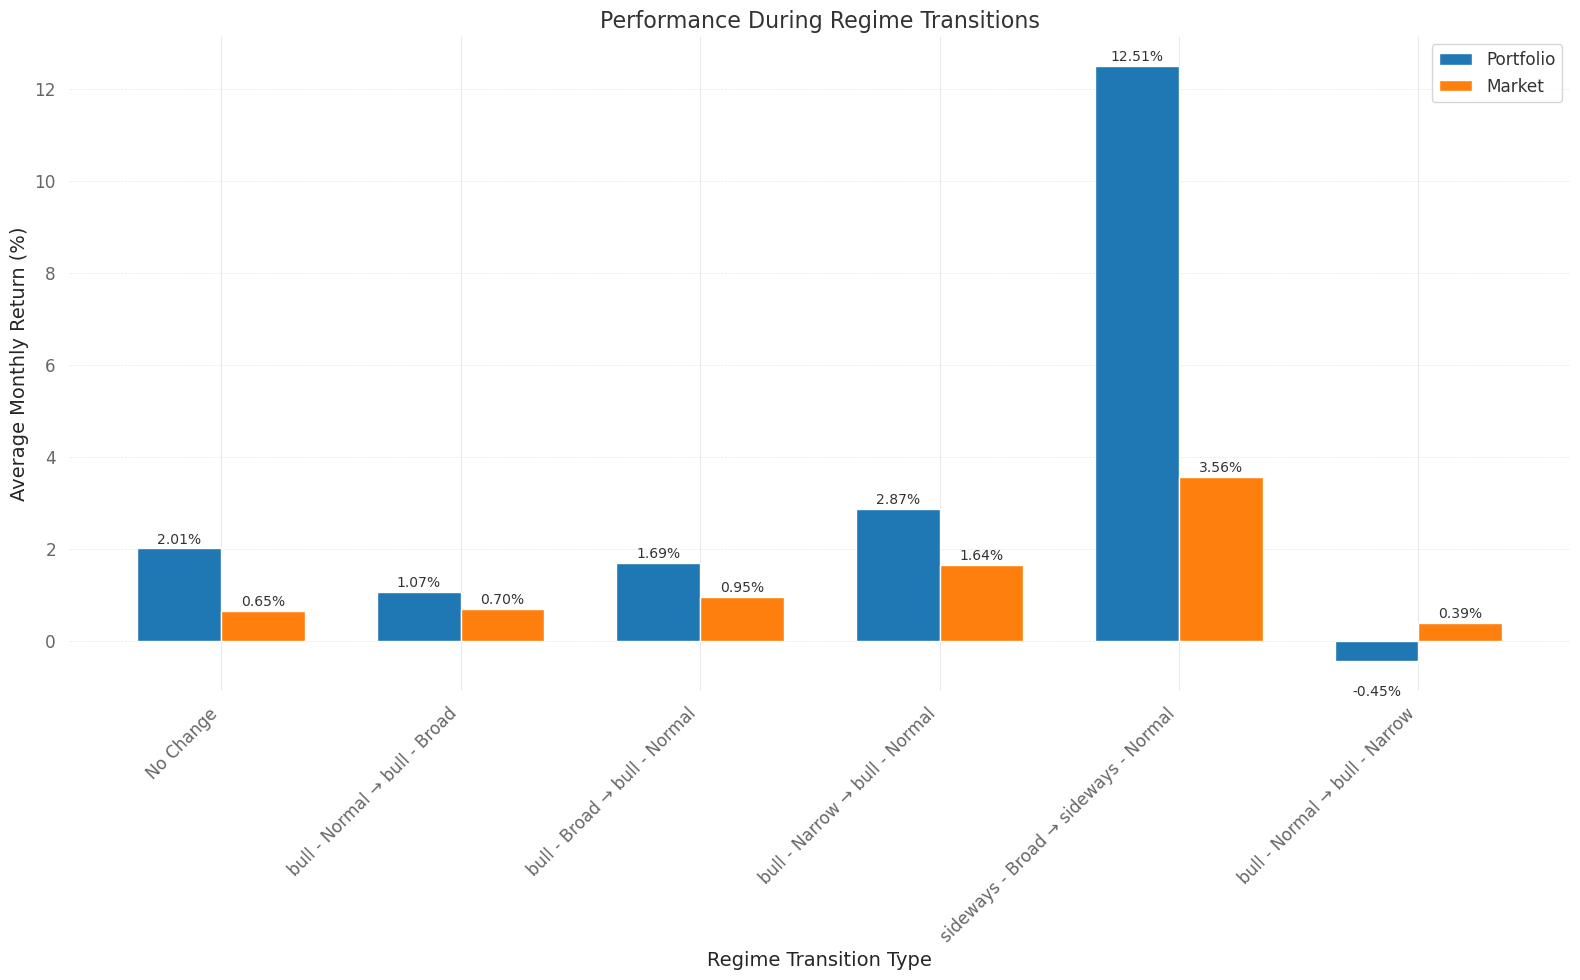

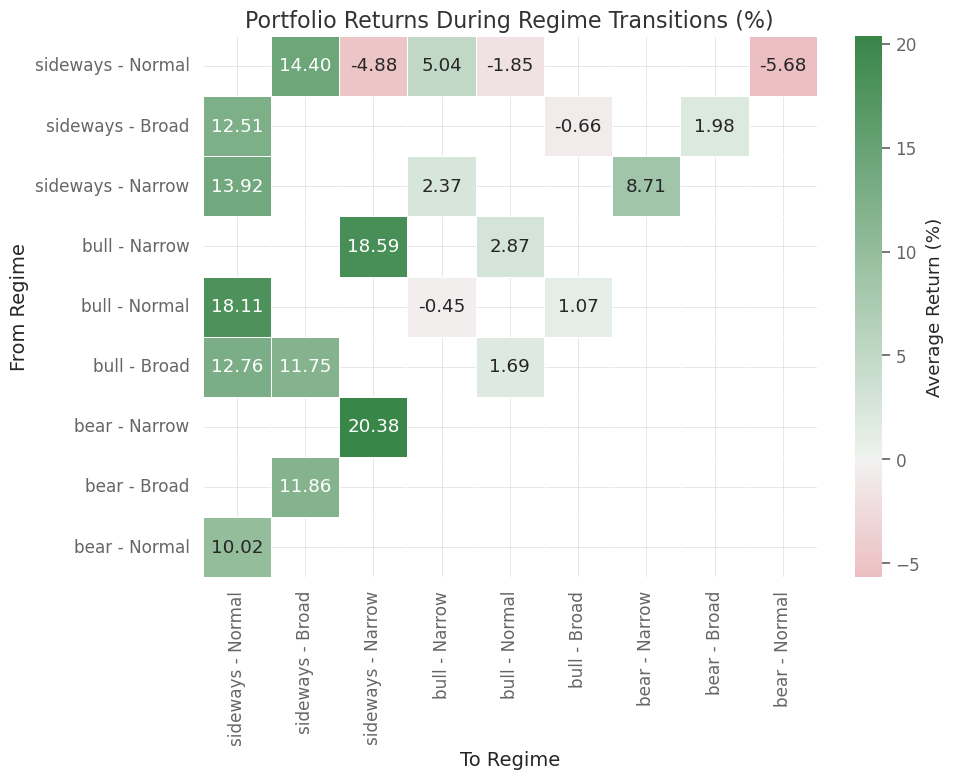

In [35]:
# Analyze performance during regime transitions
# Detect regime changes
port_returns_with_rf['prev_regime'] = port_returns_with_rf['regime'].shift(1)
port_returns_with_rf['regime_change'] = port_returns_with_rf['regime'] != port_returns_with_rf['prev_regime']

# Create a new column identifying transition periods
port_returns_with_rf['transition_type'] = 'No Change'

# Identify specific transition types
for i in range(1, len(port_returns_with_rf)):
    if port_returns_with_rf['regime_change'].iloc[i]:
        prev = port_returns_with_rf['prev_regime'].iloc[i]
        curr = port_returns_with_rf['regime'].iloc[i]
        port_returns_with_rf.loc[port_returns_with_rf.index[i], 'transition_type'] = f"{prev} → {curr}"

# Group returns by transition type
transition_returns = port_returns_with_rf.groupby('transition_type').agg({
    'portfolio_return': ['mean', 'std', 'count'],
    'Mkt_minus_RF': ['mean', 'std']
})

# Flatten the multi-index columns
transition_returns.columns = [f'{col[0]}_{col[1]}' for col in transition_returns.columns]

# Calculate Sharpe ratio
transition_returns['portfolio_sharpe'] = transition_returns['portfolio_return_mean'] / transition_returns['portfolio_return_std'] * np.sqrt(12)
transition_returns['market_sharpe'] = transition_returns['Mkt_minus_RF_mean'] / transition_returns['Mkt_minus_RF_std'] * np.sqrt(12)

# Sort by count (frequency of transition)
transition_returns = transition_returns.sort_values('portfolio_return_count', ascending=False)

# Convert returns to percentage for display
transition_returns['portfolio_return_mean'] = transition_returns['portfolio_return_mean'] * 100
transition_returns['Mkt_minus_RF_mean'] = transition_returns['Mkt_minus_RF_mean'] * 100

# Create a bar chart for transition returns
plt.figure(figsize=(16, 10))

# Use only transitions with reasonable sample size
main_transitions = transition_returns[transition_returns['portfolio_return_count'] > 3].copy()

x = np.arange(len(main_transitions))
width = 0.35

bars1 = plt.bar(x - width/2, main_transitions['portfolio_return_mean'], width, label='Portfolio', color='#1f77b4')
bars2 = plt.bar(x + width/2, main_transitions['Mkt_minus_RF_mean'], width, label='Market', color='#ff7f0e')

# Add value labels
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.05 if height > 0 else -0.5),
                f'{height:.2f}%',
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

plt.xlabel('Regime Transition Type', fontsize=14)
plt.ylabel('Average Monthly Return (%)', fontsize=14)
plt.title('Performance During Regime Transitions', fontsize=16)
plt.xticks(x, main_transitions.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create a heatmap of portfolio performance across regime pairs
# Create a pivot table of average returns for each regime pair (from → to)
regime_transitions = port_returns_with_rf[port_returns_with_rf['regime_change']].copy()

if len(regime_transitions) > 0:  # Only proceed if transitions exist
    unique_regimes = port_returns_with_rf['regime'].unique()
    transition_matrix = pd.DataFrame(index=unique_regimes, columns=unique_regimes)
    
    # Fill the matrix with average returns
    for from_regime in unique_regimes:
        for to_regime in unique_regimes:
            mask = (regime_transitions['prev_regime'] == from_regime) & (regime_transitions['regime'] == to_regime)
            if mask.sum() > 0:
                transition_matrix.loc[from_regime, to_regime] = regime_transitions.loc[mask, 'portfolio_return'].mean() * 100
            else:
                transition_matrix.loc[from_regime, to_regime] = 0  # Replace NaN with 0
    
    # Convert to float to avoid TypeError
    transition_matrix = transition_matrix.astype(float)
    
    # Create a mask for cells with zero values (no transitions)
    mask = transition_matrix == 0
    
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    
    # Custom colormap with green for positive and red for negative returns
    cmap = sns.diverging_palette(10, 133, as_cmap=True)
    
    sns.heatmap(transition_matrix, annot=True, cmap=cmap, center=0, 
                fmt='.2f', linewidths=0.5, cbar_kws={"label": "Average Return (%)"},
                mask=mask)  # Apply mask to hide cells with no transitions
    
    plt.title('Portfolio Returns During Regime Transitions (%)', fontsize=16)
    plt.xlabel('To Regime', fontsize=14)
    plt.ylabel('From Regime', fontsize=14)
    plt.tight_layout()
    plt.show()

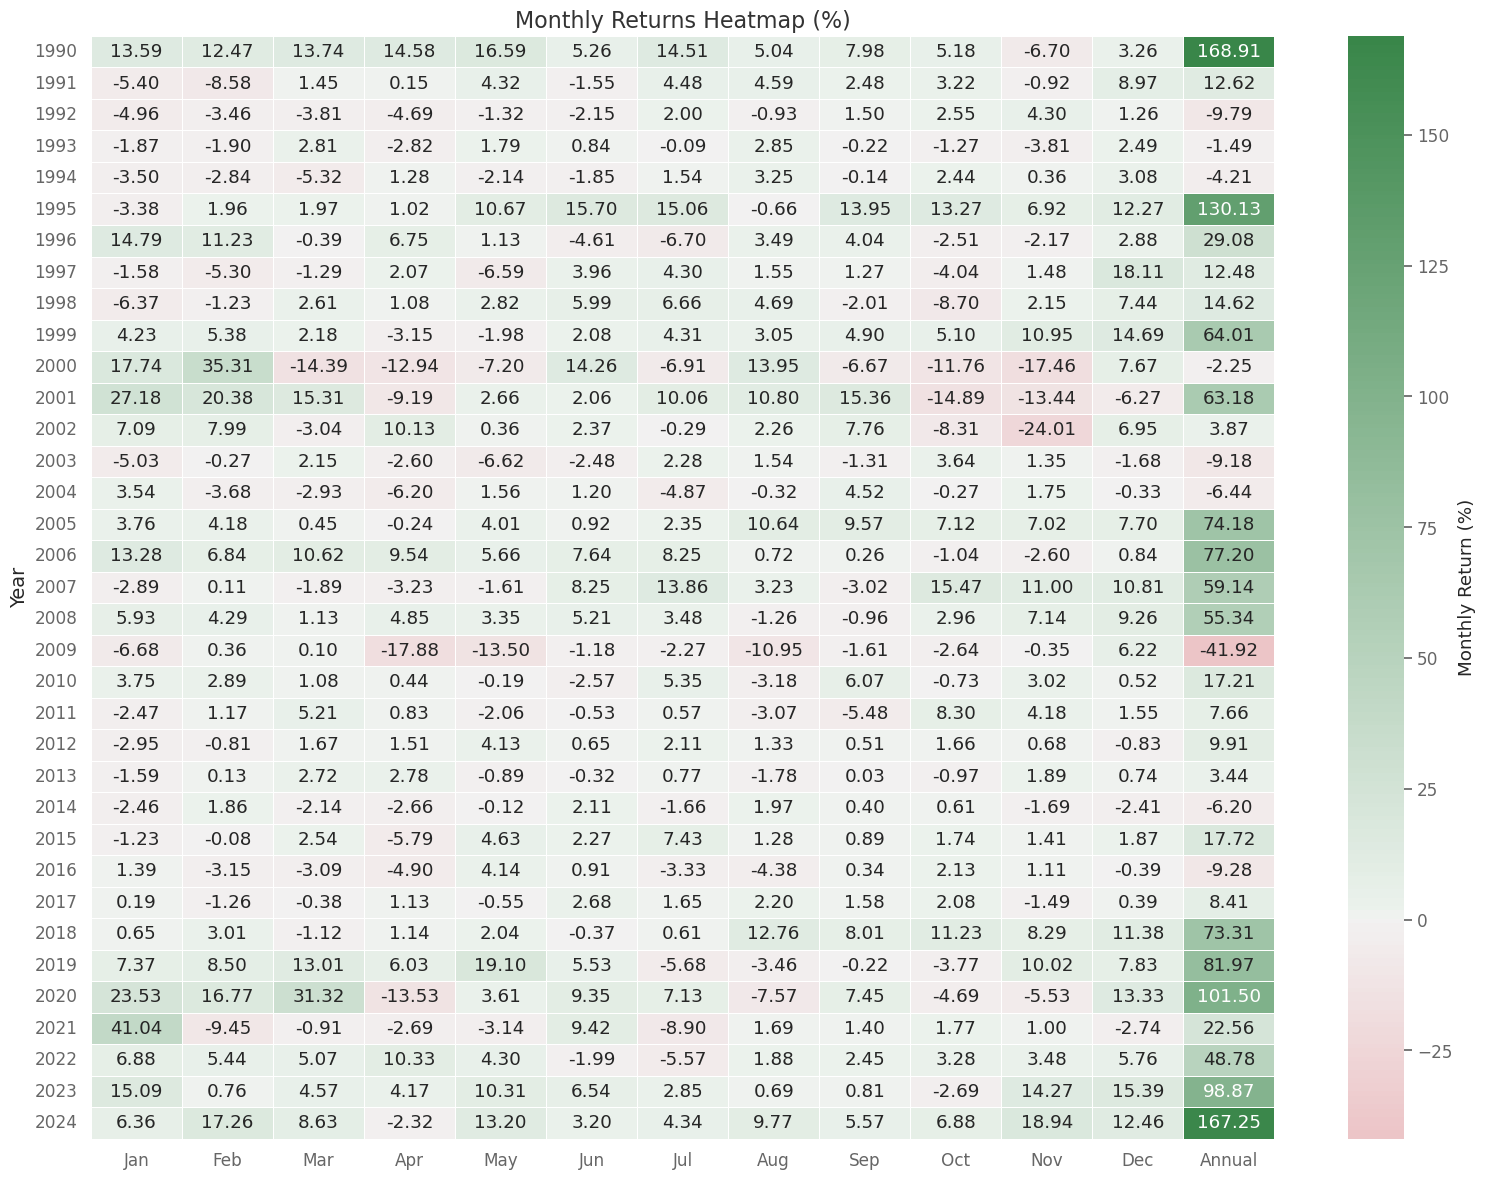

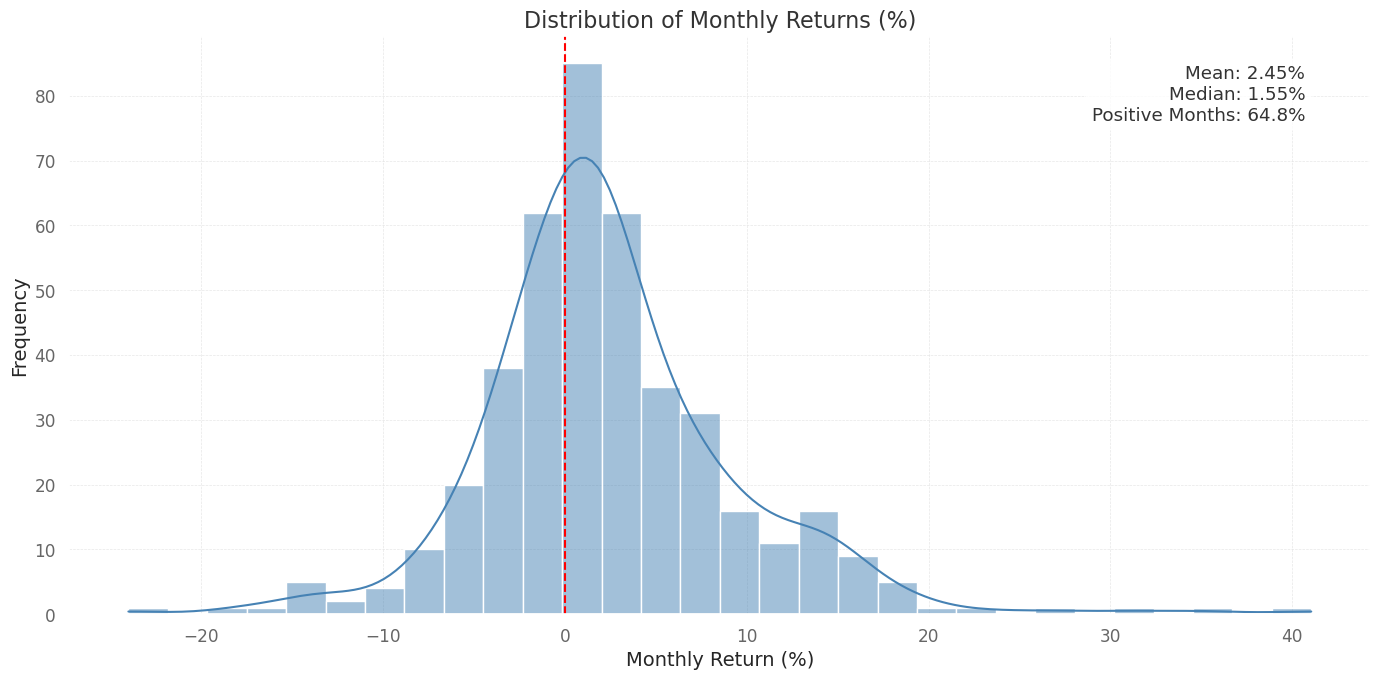

In [36]:
# Create a calendar heatmap of monthly returns
# First, prepare the data
port_returns_with_rf['Year'] = port_returns_with_rf.index.year
port_returns_with_rf['Month'] = port_returns_with_rf.index.month
port_returns_with_rf['Month_Name'] = port_returns_with_rf.index.strftime('%b')

# Create a pivot table of monthly returns by year
monthly_returns_pivot = port_returns_with_rf.pivot_table(
    index='Year', 
    columns='Month', 
    values='portfolio_return'
) * 100  # Convert to percentage

# Add month names as column labels
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_returns_pivot.columns = [month_names[col] for col in monthly_returns_pivot.columns]

# Calculate annual returns
annual_returns = port_returns_with_rf.groupby('Year')['portfolio_return'].apply(
    lambda x: (1 + x).prod() - 1
) * 100  # Convert to percentage

# Add annual returns as an additional column
monthly_returns_pivot['Annual'] = annual_returns

# Create a beautiful heatmap
plt.figure(figsize=(16, 12))

# Custom diverging colormap: red for negative, green for positive
cmap = sns.diverging_palette(10, 133, as_cmap=True)

# Create the heatmap
ax = sns.heatmap(monthly_returns_pivot, annot=True, fmt='.2f', linewidths=0.5, cmap=cmap, center=0,
                cbar_kws={'label': 'Monthly Return (%)'})

# Customize the heatmap
plt.title('Monthly Returns Heatmap (%)', fontsize=16)
plt.ylabel('Year', fontsize=14)
plt.tight_layout()
plt.show()

# Create a visualization showing the distribution of monthly returns
plt.figure(figsize=(14, 7))

# Create a histogram with KDE
sns.histplot(port_returns_with_rf['portfolio_return'] * 100, kde=True, bins=30, color='steelblue')

# Add a vertical line at zero
plt.axvline(x=0, color='red', linestyle='--')

# Add statistics to the plot
mean_return = port_returns_with_rf['portfolio_return'].mean() * 100
median_return = port_returns_with_rf['portfolio_return'].median() * 100
positive_months = (port_returns_with_rf['portfolio_return'] > 0).mean() * 100

plt.text(0.95, 0.95, f'Mean: {mean_return:.2f}%\nMedian: {median_return:.2f}%\nPositive Months: {positive_months:.1f}%',
        transform=plt.gca().transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Distribution of Monthly Returns (%)', fontsize=16)
plt.xlabel('Monthly Return (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

This study demonstrates the effectiveness of a regime-based approach to long-short equity investing. By dynamically adjusting factor exposures based on market regimes identified through term structure dynamics and market concentration metrics, our strategy achieves superior risk-adjusted returns compared to static factor approaches.

Key conclusions from our analysis include:

1. **Regime Identification**: The combination of term structure indicators and market concentration measures provides a robust framework for identifying distinct market regimes with characteristic factor performance patterns.

2. **Dynamic Factor Selection**: Different factors exhibit varying effectiveness across market regimes, validating the need for dynamic allocation rather than static factor exposure.

3. **Risk-Adjusted Performance**: Our regime-based strategy generates statistically significant alpha after controlling for market, size, and value factors, indicating that it captures return drivers not explained by traditional risk factors.

4. **Drawdown Mitigation**: The strategy demonstrates enhanced downside protection during market stress periods, with lower maximum drawdowns and faster recovery times compared to the market benchmark.

5. **Transition Performance**: The strategy adapts effectively to regime transitions, capturing upside during recovery phases while offering protection during market deterioration.

These findings have important implications for institutional investors and asset managers seeking to enhance portfolio returns through factor investing while maintaining robust risk management. The methodology presented in this paper provides a practical framework for implementing dynamic factor allocation strategies based on changing market conditions.

### Limitations and Future Research

While our study presents promising results, several limitations should be acknowledged. First, transaction costs and market impact have not been fully incorporated, which could affect the net returns of the strategy, especially in less liquid market regimes. Second, our regime identification approach relies on ex-post calculation of market concentration metrics, which may introduce some look-ahead bias despite our efforts to use lagged indicators.

Future research could explore several extensions to our approach:
- Incorporating additional regime indicators such as volatility regimes or monetary policy regimes
- Testing alternative factor definitions and combinations within each regime
- Exploring machine learning techniques for regime identification and factor selection
- Extending the analysis to international markets and alternative asset classes

## References

Bender, J., Briand, R., Melas, D., & Subramanian, R. A. (2013). Foundations of Factor Investing. *MSCI Research Insight*.

Blitz, D., & van Vliet, P. (2008). Global Tactical Cross-Asset Allocation: Applying Value and Momentum Across Asset Classes. *Journal of Portfolio Management*, 35(1), 23-38.

Fama, E. F., & French, K. R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics*, 33(1), 3-56.

Harvey, C. R., Liu, Y., & Zhu, H. (2016). ... and the Cross-Section of Expected Returns. *Review of Financial Studies*, 29(1), 5-68.

Hodges, P., Hogan, K., Peterson, J. R., & Ang, A. (2017). Factor Timing with Cross-Sectional and Time-Series Predictors. *Journal of Portfolio Management*, 44(1), 30-43.

Ilmanen, A., Israel, R., Moskowitz, T. J., Thapar, A., & Wang, F. (2021). How Do Factor Premia Vary Over Time? A Century of Evidence. *Journal of Investment Management*, 19(4), 5-37.

Jacobs, B. I., & Levy, K. N. (2014). Smart Beta versus Smart Alpha. *Journal of Portfolio Management*, 40(4), 4-7.

Jegadeesh, N., & Titman, S. (1993). Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency. *Journal of Finance*, 48(1), 65-91.

Keller, W. J., & Van Putten, A. B. (2012). Generalized Momentum and Flexible Asset Allocation (FAA): An Heuristic Approach. *Journal of Asset Management*, 13(6), 385-413.

Pastor, L., & Stambaugh, R. F. (2003). Liquidity Risk and Expected Stock Returns. *Journal of Political Economy*, 111(3), 642-685.